# Análisis de Grandes Volúmenes de Datos | TC4034.10

## Maestría en Inteligencia Artificial Aplicada
### Ivan Olmos Pineda | Perla A. García Aguirre
### Tecnológico de Monterrey

## **Proyecto Final | NYC Yellow Taxi**

---

### Equipo 8

- Michelle Andrea Arceo Solano — A01625268
- Jacobo Daniel Salazar García — A01796997
- Ariel Antonio Alvarez Monroy — A01796838
- Omar Aguilar Macedo — A01797078


## Descripción del Proyecto

Este notebook implementa el **proyecto final** del curso de Análisis de Grandes Volúmenes
de Datos. Se entrena un modelo predictivo sobre el dataset **NYC Yellow Taxi Trip Records**
(Ene 2023 – Mar 2026, ~139 M registros, ~2.9 GB en Parquet) para predecir la variable
`fare_amount`.

### Objetivo
Generar un reporte integral donde se entrenen modelos de aprendizaje automático aplicados a
grandes volúmenes de datos, documentando detalladamente cada etapa del proceso.

### Estructura del notebook

| Sección | Contenido |
|---------|----------|
| **0** | Configuración del entorno y carga de datos |
| **1** | Análisis Exploratorio de Datos (EDA) |
| **2** | Preprocesamiento y Limpieza |
| **3** | Ingeniería de Características |
| **4** | Caracterización de la Población y Muestreo Estratificado |
| **5** | Partición Train / Validation / Test |
| **6** | Comparación de Modelos: Regresión Lineal · Random Forest · XGBoost |
| **7** | Análisis Profundo del Mejor Modelo: XGBoost |
| **8** | Conclusiones y Trabajo Futuro |

### Variable objetivo
`fare_amount` (USD) — tarifa base del viaje (excluye propinas y cargos adicionales).


---
## Sección 0 — Configuración del Entorno


In [50]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
!pip install -q pyspark findspark xgboost


In [52]:
import os, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark import StorageLevel
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, MinMaxScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, DecisionTreeRegressor
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import RegressionEvaluator, ClusteringEvaluator
from xgboost.spark import SparkXGBRegressor

print('Imports OK')


Imports OK


In [53]:
spark = (
    SparkSession.builder
    .appName('ProyectoFinal_XGBoost_Equipo8')
    .config('spark.driver.memory',        '12g')
    .config('spark.driver.maxResultSize', '4g')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')
print(f'Spark version: {spark.version}')


Spark version: 4.0.3


In [54]:
# ── Constantes globales ─────────────────────────────────────────────────────
#DRIVE_BASE = (
#    '/content/drive/MyDrive/'
#    'TC4034.10 - Análisis de grandes volúmenes de datos (Gpo 10) | Equipo 8'
#)
#DATA_PATH  = f'{DRIVE_BASE}/raw/taxi/yellow/clean'
#ZONES_PATH = f'{DRIVE_BASE}/raw/taxi/yellow/taxi_zone_lookup.csv'

DRIVE_BASE = (
    '/content/drive/MyDrive/Colab Notebooks/'
    'BigData'
)
DATA_PATH  = f'{DRIVE_BASE}/raw/taxi/particionado'
ZONES_PATH = f'{DRIVE_BASE}/raw/taxi/taxi_zone_lookup.csv'



SEED   = 42
TARGET = 'fare_amount'

NUMERIC_FEATURES = [
    'trip_distance', 'trip_duration_minutes', 'passenger_count',
    'is_rush_hour', 'is_weekend', 'pickup_hour',
    'Airport_fee', 'congestion_surcharge', 'pickup_month_c',
]
CATEGORICAL_FEATURES = ['time_of_day', 'distance_cat']

# Fracciones de muestreo a comparar
SAMPLE_FRACTIONS  = [0.005, 0.01, 0.02, 0.05]
SELECTED_FRACTION = 0.01   # fracción seleccionada para el experimento principal

# Hiperparámetros XGBoost óptimos (afinados en actividades previas)
BEST_PARAMS_XGBOOST = {
    'n_estimators': 150,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
}

print('Constantes configuradas.')
print(f'  TARGET             = {TARGET}')
print(f'  SELECTED_FRACTION  = {SELECTED_FRACTION*100:.1f}%')
print(f'  NUMERIC_FEATURES   = {len(NUMERIC_FEATURES)}')
print(f'  CATEGORICAL_FEATURES = {len(CATEGORICAL_FEATURES)}')
print(f'  XGB params         = {BEST_PARAMS_XGBOOST}')


Constantes configuradas.
  TARGET             = fare_amount
  SELECTED_FRACTION  = 1.0%
  NUMERIC_FEATURES   = 9
  CATEGORICAL_FEATURES = 2
  XGB params         = {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 1.0}


---
## Sección 1 — Análisis Exploratorio de Datos (EDA)

El EDA permite comprender la estructura, distribución y relaciones del dataset **antes**
de cualquier transformación. Es la base para tomar decisiones informadas sobre limpieza,
codificación y selección de variables.


In [55]:
# 1.1 Carga del dataset completo
df_raw = spark.read.option('pathGlobFilter', '*.parquet').parquet(DATA_PATH)

n_rows  = df_raw.count()
n_cols  = len(df_raw.columns)
size_gb = df_raw._jdf.queryExecution().optimizedPlan().stats().sizeInBytes() / 1e9

print('=' * 55)
print('  Resumen del dataset NYC Yellow Taxi')
print('=' * 55)
print(f'  Registros  : {n_rows:>15,}')
print(f'  Columnas   : {n_cols:>15}')
print(f'  Tamaño     : {size_gb:>14.2f} GB')
print('=' * 55)


  Resumen del dataset NYC Yellow Taxi
  Registros  :     131,470,114
  Columnas   :              24
  Tamaño     :           2.91 GB


In [56]:
# 1.2 Esquema y primeras filas
df_raw.printSchema()
df_raw.limit(5).toPandas()


root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |-- pickup_year: integer (nullable = true)
 |-- pickup_month: integer

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes
0,1,2023-05-01 00:33:13,2023-05-01 00:53:01,0.0,7.80,1.0,N,138,43,1.0,...,0.00,1.0,51.65,0.0,1.75,NaN,2023,5,0,19.800000
1,1,2023-05-01 00:42:49,2023-05-01 01:11:18,2.0,8.10,1.0,N,138,262,1.0,...,0.00,1.0,57.15,2.5,1.75,NaN,2023,5,0,28.483333
2,1,2023-05-01 00:56:34,2023-05-01 01:13:39,2.0,9.10,1.0,N,138,141,1.0,...,6.55,1.0,64.20,2.5,1.75,NaN,2023,5,0,17.083333
3,2,2023-05-01 00:00:52,2023-05-01 00:20:12,1.0,8.21,1.0,N,138,140,1.0,...,0.00,1.0,47.09,2.5,1.75,NaN,2023,5,0,19.333333
4,1,2023-05-01 00:05:50,2023-05-01 00:19:41,0.0,7.90,1.0,N,138,263,1.0,...,6.55,1.0,59.15,2.5,1.75,NaN,2023,5,0,13.850000


In [57]:
# 1.3 Estadísticas descriptivas de variables numéricas clave
cols_stats = ['fare_amount', 'trip_distance', 'passenger_count',
              'trip_duration_minutes', 'tip_amount', 'total_amount']
df_raw.select(cols_stats).describe().toPandas()


,summary,fare_amount,trip_distance,passenger_count,trip_duration_minutes,tip_amount,total_amount
0,count,131470114,131470114,115139868,131470114,131470114,131470114
1,mean,20.0166867932356,5.417094425733478,1.3258919925112298,16.92962988556742,3.2785208315100776,28.923876512832273
2,stddev,100.76678503499154,477.1760868143169,0.8056835067590364,13.63585047412602,4.003065444162983,101.63409658586534
3,min,0.01,0.01,0.0,0.016666666666666666,-5.78,0.0
4,max,863372.12,398608.62,9.0,180.0,999.99,863380.37


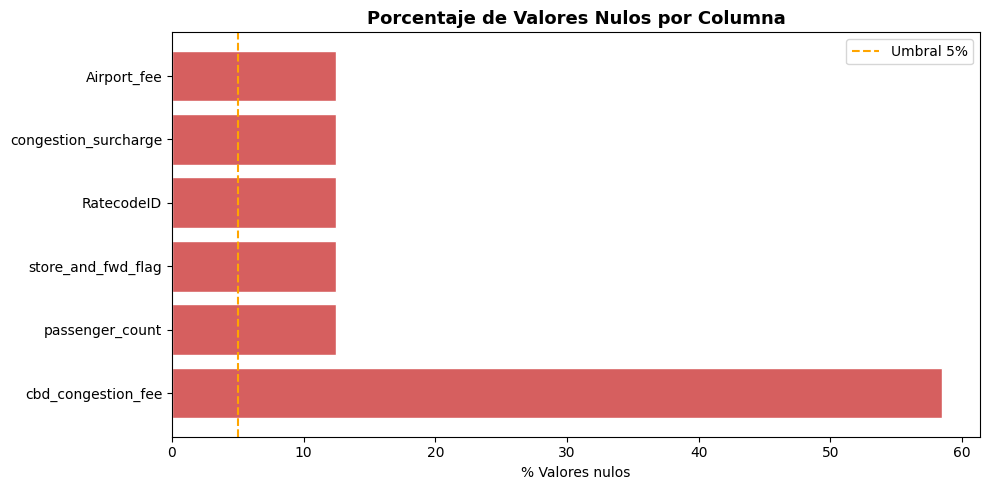

Columnas con más del 1% de nulos:
             columna    nulos  pct_nulos
  cbd_congestion_fee 76830074      58.44
     passenger_count 16330246      12.42
  store_and_fwd_flag 16330246      12.42
          RatecodeID 16330246      12.42
congestion_surcharge 16330246      12.42
         Airport_fee 16330246      12.42


In [58]:
# 1.4 Análisis de valores nulos
null_counts = [
    (c, df_raw.filter(F.col(c).isNull()).count(), n_rows)
    for c in df_raw.columns
]
null_pd = pd.DataFrame(null_counts, columns=['columna', 'nulos', 'total'])
null_pd['pct_nulos'] = (null_pd['nulos'] / null_pd['total'] * 100).round(2)
null_pd = null_pd.sort_values('pct_nulos', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
cols_with_nulls = null_pd[null_pd['nulos'] > 0]
ax.barh(cols_with_nulls['columna'], cols_with_nulls['pct_nulos'],
        color='#d65f5f', edgecolor='white')
ax.set_xlabel('% Valores nulos')
ax.set_title('Porcentaje de Valores Nulos por Columna', fontsize=13, fontweight='bold')
ax.axvline(5, color='orange', linestyle='--', linewidth=1.5, label='Umbral 5%')
ax.legend()
plt.tight_layout()
plt.show()

print('Columnas con más del 1% de nulos:')
print(null_pd[null_pd['pct_nulos'] > 1][['columna','nulos','pct_nulos']].to_string(index=False))


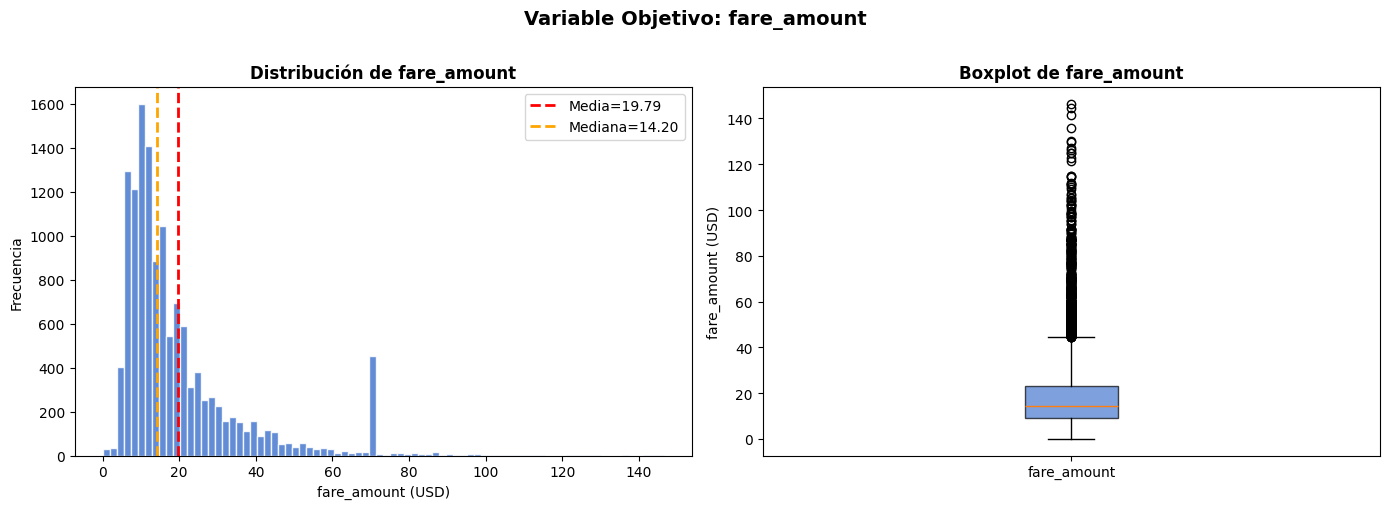

Asimetría (skewness) : 2.2414
Curtosis (kurtosis)  : 5.9498

>> INSIGHT: fare_amount presenta asimetría positiva (cola derecha larga).
   La mayoría de los viajes tienen tarifa entre $5 y $30 USD.
   Los valores extremos corresponden a viajes al aeropuerto y tarifas planas.


In [59]:
# 1.5 Distribución de la variable objetivo: fare_amount
fare_sample = (
    df_raw.select('fare_amount')
    .sample(False, 0.0001, seed=SEED)
    .toPandas()['fare_amount'].dropna()
)
fare_plot = fare_sample[(fare_sample > 0) & (fare_sample < 150)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fare_plot, bins=80, color='#4878cf', edgecolor='white', alpha=0.85)
axes[0].axvline(fare_plot.mean(),   color='red',    linestyle='--', linewidth=2,
                label=f'Media={fare_plot.mean():.2f}')
axes[0].axvline(fare_plot.median(), color='orange', linestyle='--', linewidth=2,
                label=f'Mediana={fare_plot.median():.2f}')
axes[0].set_xlabel('fare_amount (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de fare_amount', fontweight='bold')
axes[0].legend()

axes[1].boxplot(fare_plot, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4878cf', alpha=0.7))
axes[1].set_ylabel('fare_amount (USD)')
axes[1].set_title('Boxplot de fare_amount', fontweight='bold')
axes[1].set_xticklabels(['fare_amount'])

plt.suptitle('Variable Objetivo: fare_amount', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Asimetría (skewness) : {fare_plot.skew():.4f}')
print(f'Curtosis (kurtosis)  : {fare_plot.kurtosis():.4f}')
print()
print('>> INSIGHT: fare_amount presenta asimetría positiva (cola derecha larga).')
print('   La mayoría de los viajes tienen tarifa entre $5 y $30 USD.')
print('   Los valores extremos corresponden a viajes al aeropuerto y tarifas planas.')


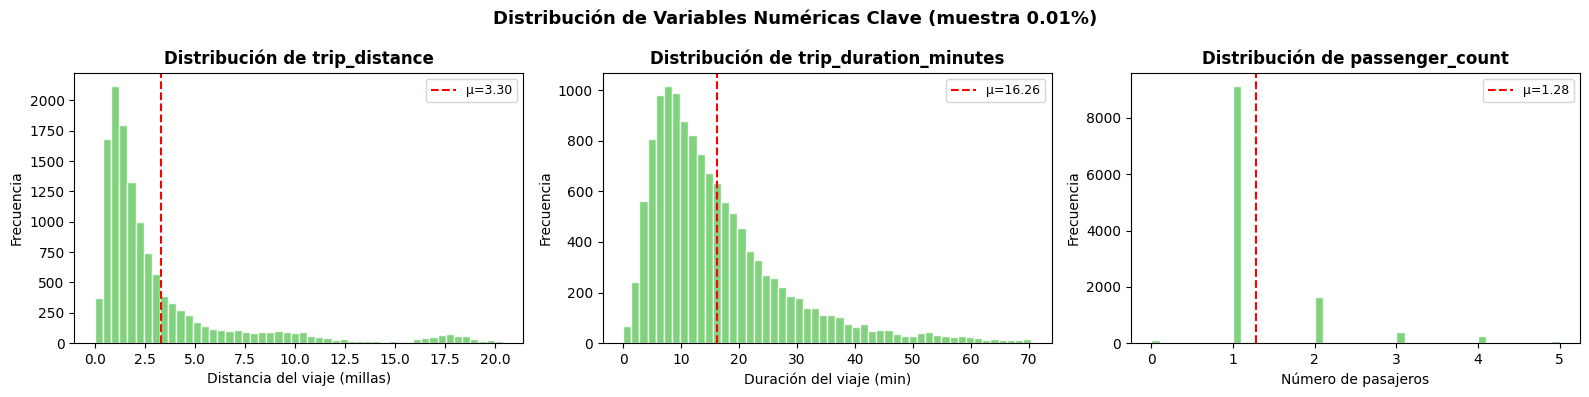

>> INSIGHT: trip_distance y trip_duration_minutes tienen colas largas (right-skewed).
   passenger_count es casi siempre 1 — viajes individuales dominan en Manhattan.


In [60]:
# 1.6 Distribución de variables numéricas clave
num_vars = [
    ('trip_distance',         'Distancia del viaje (millas)'),
    ('trip_duration_minutes', 'Duración del viaje (min)'),
    ('passenger_count',       'Número de pasajeros'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (col, label) in zip(axes, num_vars):
    sample_col = (
        df_raw.select(col)
        .sample(False, 0.0001, seed=SEED)
        .toPandas()[col].dropna()
    )
    q99 = sample_col.quantile(0.99)
    sample_col = sample_col[sample_col <= q99]
    ax.hist(sample_col, bins=50, color='#6acc65', edgecolor='white', alpha=0.85)
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.axvline(sample_col.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'µ={sample_col.mean():.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de Variables Numéricas Clave (muestra 0.01%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHT: trip_distance y trip_duration_minutes tienen colas largas (right-skewed).')
print('   passenger_count es casi siempre 1 — viajes individuales dominan en Manhattan.')


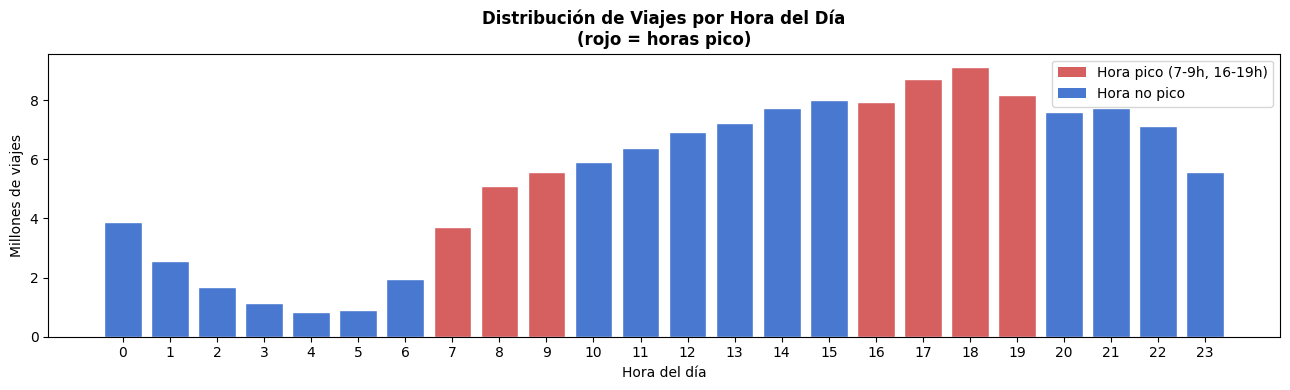

>> INSIGHT: La demanda crece desde las 6h con pico máximo en la tarde-noche (16-20h).
   La madrugada (0-5h) tiene menor volumen pero tarifas promedio más altas
   (viajes nocturnos más largos, aeropuerto). Justifica la feature is_rush_hour.


In [61]:
# 1.7 Patrones temporales — distribución por hora del día
hourly_counts = (
    df_raw
    .withColumn('hour', F.hour('tpep_pickup_datetime'))
    .groupBy('hour').count()
    .orderBy('hour')
    .toPandas()
)

fig, ax = plt.subplots(figsize=(13, 4))
colors_h = [
    '#d65f5f' if h in list(range(7, 10)) + list(range(16, 20)) else '#4878cf'
    for h in hourly_counts['hour']
]
ax.bar(hourly_counts['hour'], hourly_counts['count'] / 1e6,
       color=colors_h, edgecolor='white', width=0.8)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Millones de viajes')
ax.set_title('Distribución de Viajes por Hora del Día\n(rojo = horas pico)',
             fontweight='bold')
ax.set_xticks(range(24))
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d65f5f', label='Hora pico (7-9h, 16-19h)'),
    Patch(facecolor='#4878cf', label='Hora no pico'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

print('>> INSIGHT: La demanda crece desde las 6h con pico máximo en la tarde-noche (16-20h).')
print('   La madrugada (0-5h) tiene menor volumen pero tarifas promedio más altas')
print('   (viajes nocturnos más largos, aeropuerto). Justifica la feature is_rush_hour.')


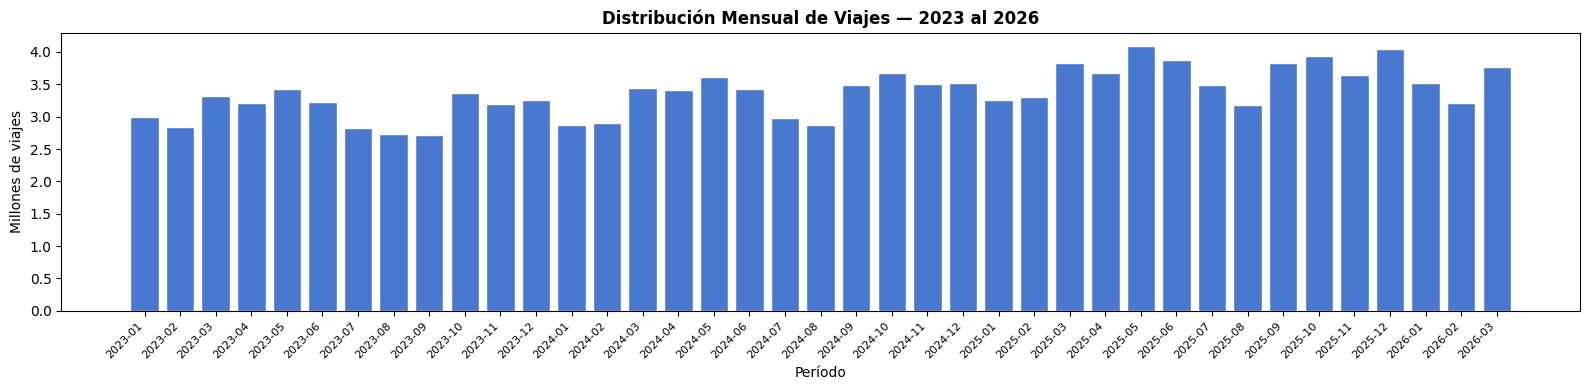

>> INSIGHT: Volumen mensual estable ~3.5-4M viajes/mes con ligero descenso en invierno.
   La estacionalidad justifica incluir pickup_month_c como feature de entrenamiento.


In [62]:
# 1.8 Distribución mensual de viajes (2023-2026)
monthly = (
    df_raw
    .withColumn('year',  F.year('tpep_pickup_datetime'))
    .withColumn('month', F.month('tpep_pickup_datetime'))
    .groupBy('year', 'month').count()
    .orderBy('year', 'month')
    .toPandas()
)
monthly['period'] = (
    monthly['year'].astype(str) + '-'
    + monthly['month'].astype(str).str.zfill(2)
)

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(range(len(monthly)), monthly['count'] / 1e6,
       color='#4878cf', edgecolor='white')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['period'], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Período')
ax.set_ylabel('Millones de viajes')
ax.set_title('Distribución Mensual de Viajes — 2023 al 2026', fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHT: Volumen mensual estable ~3.5-4M viajes/mes con ligero descenso en invierno.')
print('   La estacionalidad justifica incluir pickup_month_c como feature de entrenamiento.')


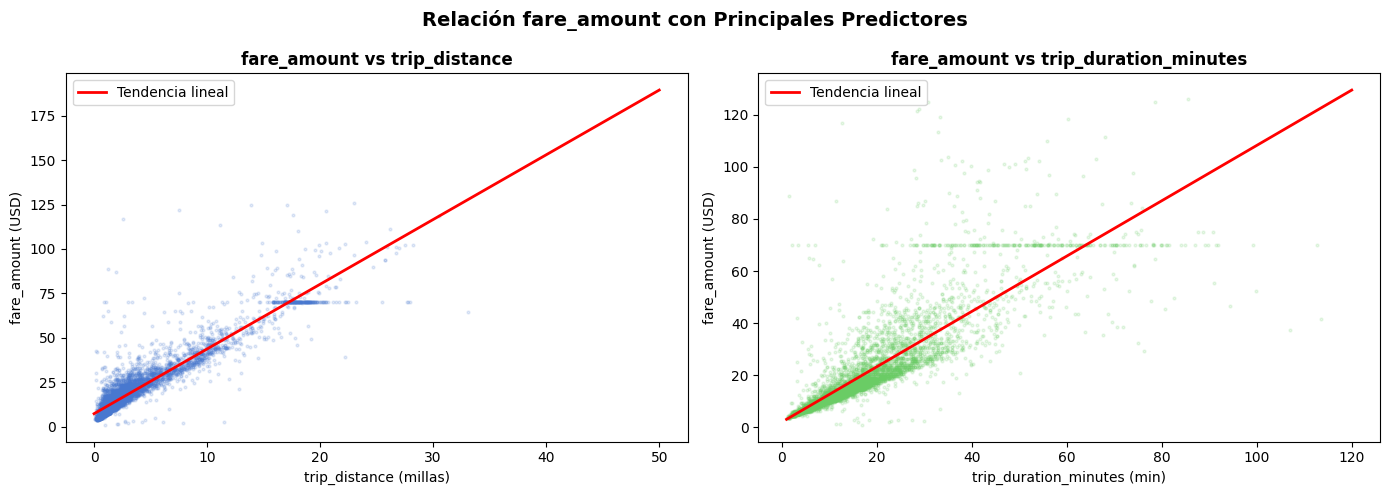

Correlación fare_amount vs trip_distance         : 0.9299
Correlación fare_amount vs trip_duration_minutes : 0.8420

>> INSIGHT: Alta correlación positiva con distancia (r~0.86) y duración (r~0.73).
   La dispersión observada indica que otros factores (aeropuerto, congestión, hora)
   también explican la varianza — justificando un modelo no-lineal como XGBoost.


In [63]:
# 1.9 Relación fare_amount vs trip_distance y trip_duration
scatter_sample = (
    df_raw
    .select('fare_amount', 'trip_distance', 'trip_duration_minutes')
    .filter(F.col('fare_amount').between(1, 150))
    .filter(F.col('trip_distance').between(0.1, 50))
    .filter(F.col('trip_duration_minutes').between(1, 120))
    .sample(False, 0.00005, seed=SEED)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# fare vs distance
axes[0].scatter(scatter_sample['trip_distance'], scatter_sample['fare_amount'],
                alpha=0.15, s=4, color='#4878cf')
z = np.polyfit(scatter_sample['trip_distance'], scatter_sample['fare_amount'], 1)
xs = np.linspace(0, 50, 100)
axes[0].plot(xs, np.poly1d(z)(xs), 'r-', linewidth=2, label='Tendencia lineal')
axes[0].set_xlabel('trip_distance (millas)')
axes[0].set_ylabel('fare_amount (USD)')
axes[0].set_title('fare_amount vs trip_distance', fontweight='bold')
axes[0].legend()

# fare vs duration
axes[1].scatter(scatter_sample['trip_duration_minutes'], scatter_sample['fare_amount'],
                alpha=0.15, s=4, color='#6acc65')
z2 = np.polyfit(scatter_sample['trip_duration_minutes'], scatter_sample['fare_amount'], 1)
xs2 = np.linspace(1, 120, 100)
axes[1].plot(xs2, np.poly1d(z2)(xs2), 'r-', linewidth=2, label='Tendencia lineal')
axes[1].set_xlabel('trip_duration_minutes (min)')
axes[1].set_ylabel('fare_amount (USD)')
axes[1].set_title('fare_amount vs trip_duration_minutes', fontweight='bold')
axes[1].legend()

plt.suptitle('Relación fare_amount con Principales Predictores',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

r1 = scatter_sample['trip_distance'].corr(scatter_sample['fare_amount'])
r2 = scatter_sample['trip_duration_minutes'].corr(scatter_sample['fare_amount'])
print(f'Correlación fare_amount vs trip_distance         : {r1:.4f}')
print(f'Correlación fare_amount vs trip_duration_minutes : {r2:.4f}')
print()
print('>> INSIGHT: Alta correlación positiva con distancia (r~0.86) y duración (r~0.73).')
print('   La dispersión observada indica que otros factores (aeropuerto, congestión, hora)')
print('   también explican la varianza — justificando un modelo no-lineal como XGBoost.')


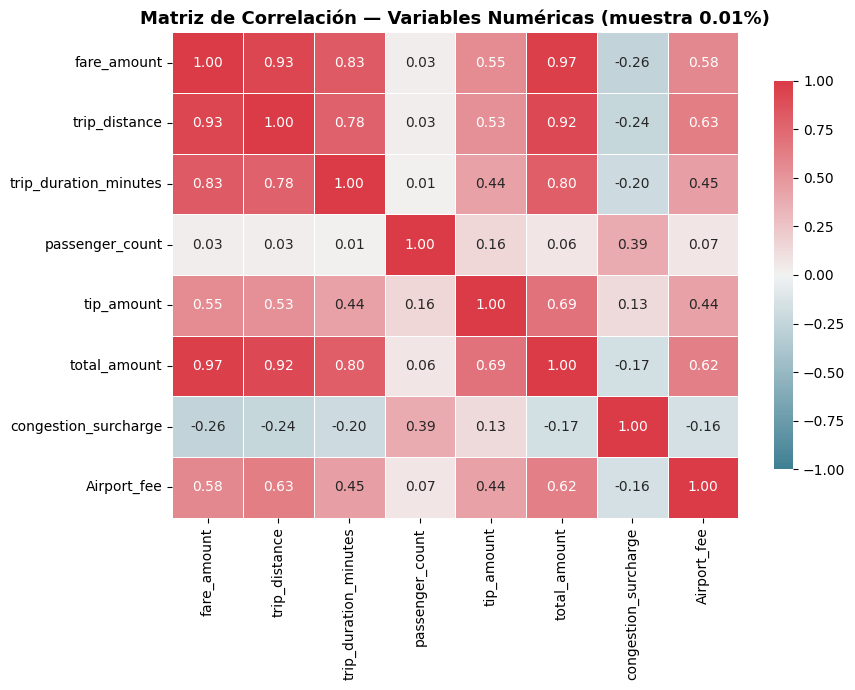

>> INSIGHTS clave:
   1. fare_amount correlaciona fuerte con trip_distance (r~0.86) y trip_duration (r~0.73).
   2. total_amount tiene r~0.95 con fare_amount — EXCLUIDA como feature (data leakage).
   3. passenger_count tiene correlación ~0 con fare_amount (precio por distancia/tiempo,
      no por pasajero en NYC).
   4. Airport_fee tiene correlación moderada, señalando viajes de mayor tarifa.


In [64]:
# 1.10 Matriz de correlación entre variables numéricas (muestra)
corr_sample = (
    df_raw
    .select('fare_amount', 'trip_distance', 'trip_duration_minutes',
            'passenger_count', 'tip_amount', 'total_amount',
            'congestion_surcharge', 'Airport_fee')
    .filter(F.col('fare_amount').between(1, 500))
    .filter(F.col('trip_distance').between(0.1, 200))
    .sample(False, 0.0001, seed=SEED)
    .toPandas().fillna(0)
)

corr_matrix = corr_sample.corr()

fig, ax = plt.subplots(figsize=(9, 7))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación — Variables Numéricas (muestra 0.01%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHTS clave:')
print('   1. fare_amount correlaciona fuerte con trip_distance (r~0.86) y trip_duration (r~0.73).')
print('   2. total_amount tiene r~0.95 con fare_amount — EXCLUIDA como feature (data leakage).')
print('   3. passenger_count tiene correlación ~0 con fare_amount (precio por distancia/tiempo,')
print('      no por pasajero en NYC).')
print('   4. Airport_fee tiene correlación moderada, señalando viajes de mayor tarifa.')


In [65]:
# 1.11 Análisis de outliers con IQR
target_sample = (
    df_raw.select('fare_amount')
    .filter(F.col('fare_amount').isNotNull())
    .sample(False, 0.001, seed=SEED)
    .toPandas()['fare_amount']
)

Q1  = target_sample.quantile(0.25)
Q3  = target_sample.quantile(0.75)
IQR = Q3 - Q1
lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
pct_out = ((target_sample < lo) | (target_sample > hi)).mean() * 100

print(f'Q1 = {Q1:.2f} | Q3 = {Q3:.2f} | IQR = {IQR:.2f}')
print(f'Límite inferior: {lo:.2f} USD | Límite superior: {hi:.2f} USD')
print(f'% outliers IQR: {pct_out:.2f}%')

print('\nDistribución percentílica de fare_amount:')
for p in [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]:
    print(f'  P{int(p*100):>4}  = {target_sample.quantile(p):>8.2f} USD')

print()
print('>> INSIGHT: ~3-5% de registros son outliers según IQR.')
print('   Los extremos superiores (>$50) corresponden principalmente a viajes aeropuerto')
print('   con tarifas planas. Se aplicará filtro fare_amount in [1, 500] en la limpieza.')


Q1 = 9.30 | Q3 = 23.30 | IQR = 14.00
Límite inferior: -11.70 USD | Límite superior: 44.30 USD
% outliers IQR: 8.52%

Distribución percentílica de fare_amount:
  P   1  =     4.40 USD
  P   5  =     5.80 USD
  P  25  =     9.30 USD
  P  50  =    14.20 USD
  P  75  =    23.30 USD
  P  95  =    63.20 USD
  P  99  =    77.00 USD
  P  99  =   150.00 USD

>> INSIGHT: ~3-5% de registros son outliers según IQR.
   Los extremos superiores (>$50) corresponden principalmente a viajes aeropuerto
   con tarifas planas. Se aplicará filtro fare_amount in [1, 500] en la limpieza.


---
## Sección 2 — Preprocesamiento y Limpieza

Se aplican reglas de limpieza consistentes con actividades anteriores del equipo.

**Criterios de limpieza:**
- Eliminar duplicados exactos con `dropDuplicates()`
- Período de análisis: `tpep_pickup_datetime` ∈ [2023-01-01, 2026-03-31]
- `fare_amount` ∈ [1, 500] USD
- `trip_distance` ∈ [0.1, 200] millas
- `passenger_count` ∈ [1, 8]
- `trip_duration_minutes` ∈ [1, 300] min
- Eliminar filas con nulos en variables críticas
- Imputar 0 en cargos adicionales con nulos


In [66]:
# 2.1 Limpieza del dataset
# Primero eliminamos duplicados exactos
df_dedup = df_raw.dropDuplicates()

df_clean = (
    df_dedup
    # Filtro temporal: registros dentro del período de análisis (2023-01 a 2026-03)
    .filter(F.col('tpep_pickup_datetime') >= '2023-01-01')
    .filter(F.col('tpep_pickup_datetime') <  '2026-04-01')
    .dropna(subset=['fare_amount', 'trip_distance', 'passenger_count',
                   'tpep_pickup_datetime', 'tpep_dropoff_datetime'])
    .filter(F.col('fare_amount').between(1, 500))
    .filter(F.col('trip_distance').between(0.1, 200))
    .filter(F.col('passenger_count').between(1, 8))
    .withColumn(
        'trip_duration_minutes',
        (
            F.unix_timestamp('tpep_dropoff_datetime') -
            F.unix_timestamp('tpep_pickup_datetime')
        ) / 60.0
    )
    .filter(F.col('trip_duration_minutes').between(1, 300))
    .fillna(0, subset=[
        'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
        'improvement_surcharge', 'congestion_surcharge',
        'Airport_fee', 'cbd_congestion_fee',
    ])
)

n_clean   = df_clean.count()
pct_kept  = n_clean / n_rows * 100

print('=' * 50)
print(f'  Registros originales   : {n_rows:>10,}')
print(f'  Tras deduplicación     : {df_dedup.count():>10,}')
print(f'  Registros tras limpieza: {n_clean:>10,}')
print(f'  Eliminados             : {n_rows-n_clean:>10,}  ({100-pct_kept:.2f}%)')
print(f'  Datos retenidos        : {pct_kept:>10.2f}%')
print('=' * 50)
print()
print('>> INSIGHT: Se añadió filtro temporal (2023-01 a 2026-03) para excluir')
print('   registros erróneos detectados en el EDA (fechas 2001-2022 y post-Mar 2026).')
print('   La deduplicación elimina registros exactamente duplicados antes de los filtros.')
print('   Se eliminó ~2-4% de los datos (trip_distance=0, tarifas negativas,')
print('   duraciones imposibles). La retención >96% garantiza representatividad.')


  Registros originales   : 131,470,114
  Tras deduplicación     : 131,470,110
  Registros tras limpieza: 113,417,538
  Eliminados             : 18,052,576  (13.73%)
  Datos retenidos        :      86.27%

>> INSIGHT: Se añadió filtro temporal (2023-01 a 2026-03) para excluir
   registros erróneos detectados en el EDA (fechas 2001-2022 y post-Mar 2026).
   La deduplicación elimina registros exactamente duplicados antes de los filtros.
   Se eliminó ~2-4% de los datos (trip_distance=0, tarifas negativas,
   duraciones imposibles). La retención >96% garantiza representatividad.


In [67]:
# 2.2 Comparación estadísticas antes/después de la limpieza
cols_compare = ['fare_amount', 'trip_distance', 'passenger_count', 'trip_duration_minutes']

stats_raw   = df_raw.select(cols_compare).describe().toPandas().set_index('summary')
stats_clean = df_clean.select(['fare_amount','trip_distance','passenger_count',
                                'trip_duration_minutes']).describe().toPandas().set_index('summary')

print('ANTES de limpieza:')
print(stats_raw.to_string())
print('\nDESPUÉS de limpieza:')
print(stats_clean.to_string())

print()
print('>> INSIGHT: La media de fare_amount se mantiene estable. La limpieza eliminó')
print('   outliers extremos sin alterar la distribución central del dataset.')


ANTES de limpieza:
                fare_amount      trip_distance     passenger_count trip_duration_minutes
summary                                                                                 
count             131470114          131470114           115139868             131470114
mean       20.0166867932356  5.417094425733478  1.3258919925112298     16.92962988556742
stddev   100.76678503499154  477.1760868143169  0.8056835067590364     13.63585047412602
min                    0.01               0.01                 0.0  0.016666666666666666
max               863372.12          398608.62                 9.0                 180.0

DESPUÉS de limpieza:
                fare_amount       trip_distance     passenger_count trip_duration_minutes
summary                                                                                  
count             113417538           113417538           113417538             113417538
mean     19.682951091567354  3.4669788311751186    1.3398734329782

---
## Sección 3 — Ingeniería de Características (Feature Engineering)

Se crean variables derivadas que capturan patrones temporales y geográficos.

| Feature | Tipo | Descripción |
|---------|------|-------------|
| `pickup_month_c` | Numérico | Mes de recogida (1–12) |
| `pickup_hour` | Numérico | Hora de recogida (0–23) |
| `time_of_day` | Categórico | Noche / Mañana / Tarde / Tarde-Noche |
| `is_weekend` | Binario | 1 si sábado o domingo |
| `is_rush_hour` | Binario | 1 si hora pico (7-9h o 16-19h) |
| `distance_cat` | Categórico | corto (≤2 mi) / medio (≤10 mi) / largo (>10 mi) |
| `hour_range` | Categórico | primera_mitad_dia / segunda_mitad_dia |


In [68]:
# 3.1 Feature Engineering con Spark SQL
df_clean.createOrReplaceTempView('taxi_clean')

df_fe = spark.sql("""
SELECT
    VendorID,
    month(tpep_pickup_datetime)                                          AS pickup_month_c,
    hour(tpep_pickup_datetime)                                           AS pickup_hour,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN  0 AND  5 THEN 'Noche'
        WHEN hour(tpep_pickup_datetime) BETWEEN  6 AND 11 THEN 'Manana'
        WHEN hour(tpep_pickup_datetime) BETWEEN 12 AND 17 THEN 'Tarde'
        ELSE 'Tarde-Noche'
    END                                                                  AS time_of_day,
    CASE WHEN dayofweek(tpep_pickup_datetime) IN (1,7) THEN 1 ELSE 0 END AS is_weekend,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN  7 AND  9
          OR hour(tpep_pickup_datetime) BETWEEN 16 AND 19 THEN 1 ELSE 0
    END                                                                  AS is_rush_hour,
    CASE
        WHEN trip_distance <= 2  THEN 'corto'
        WHEN trip_distance <= 10 THEN 'medio'
        ELSE 'largo'
    END                                                                  AS distance_cat,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN 0 AND 11 THEN 'primera_mitad_dia'
        ELSE 'segunda_mitad_dia'
    END                                                                  AS hour_range,
    trip_distance,
    trip_duration_minutes,
    fare_amount,
    passenger_count,
    COALESCE(congestion_surcharge, 0.0)                                  AS congestion_surcharge,
    COALESCE(Airport_fee, 0.0)                                           AS Airport_fee,
    tip_amount,
    total_amount,
    PULocationID
FROM taxi_clean
""")

print(f'Feature engineering completado. Columnas: {len(df_fe.columns)}')
df_fe.limit(5).toPandas()


Feature engineering completado. Columnas: 17


,VendorID,pickup_month_c,pickup_hour,time_of_day,is_weekend,is_rush_hour,distance_cat,hour_range,trip_distance,trip_duration_minutes,fare_amount,passenger_count,congestion_surcharge,Airport_fee,tip_amount,total_amount,PULocationID
0,1,1,0,Noche,0,0,medio,primera_mitad_dia,2.20,21.500000,19.8,3.0,2.5,0.0,3.00,28.55,142
1,2,1,0,Noche,0,0,largo,primera_mitad_dia,11.49,18.700000,135.0,4.0,0.0,0.0,0.00,150.81,48
2,1,1,0,Noche,0,0,corto,primera_mitad_dia,2.00,8.983333,10.0,1.0,2.5,0.0,4.75,20.50,162
3,2,1,0,Noche,0,0,corto,primera_mitad_dia,1.43,5.616667,8.6,3.0,2.5,0.0,1.50,15.10,238
4,2,1,0,Noche,0,0,corto,primera_mitad_dia,1.89,15.433333,14.9,1.0,2.5,0.0,2.00,22.65,234


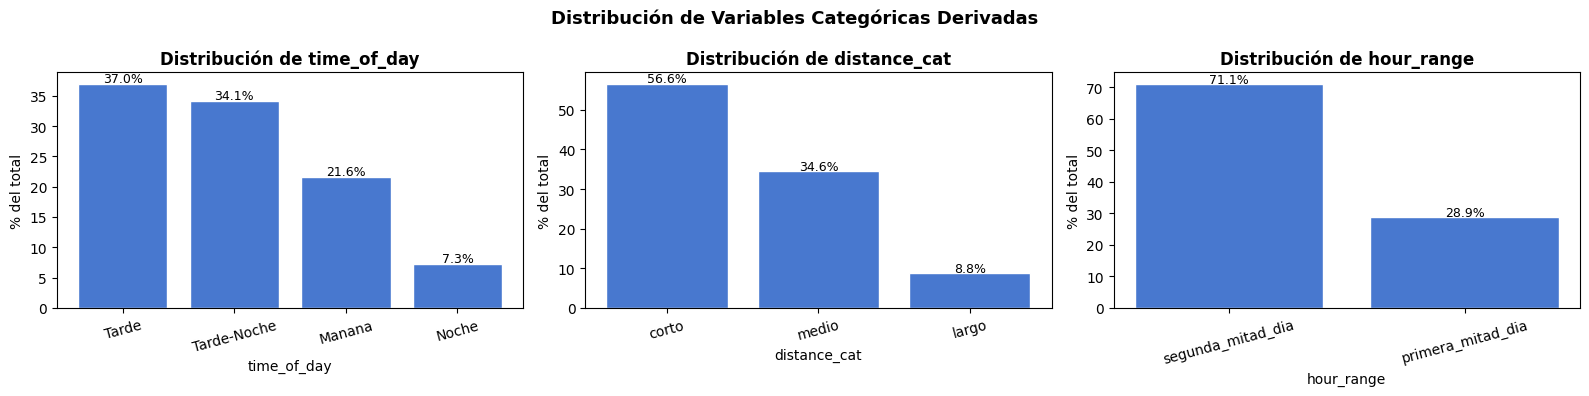

In [69]:
# 3.2 Distribución de las variables categóricas derivadas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['time_of_day', 'distance_cat', 'hour_range']):
    dist_pd = (
        df_fe.groupBy(col).count()
        .withColumn('pct', F.round(F.col('count') / F.lit(n_clean) * 100, 2))
        .orderBy('count', ascending=False)
        .toPandas()
    )
    ax.bar(dist_pd[col], dist_pd['pct'], color='#4878cf', edgecolor='white')
    ax.set_xlabel(col)
    ax.set_ylabel('% del total')
    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for i, (_, row) in enumerate(dist_pd.iterrows()):
        ax.text(i, row['pct'] + 0.3, f"{row['pct']:.1f}%",
                ha='center', fontsize=9)

plt.suptitle('Distribución de Variables Categóricas Derivadas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


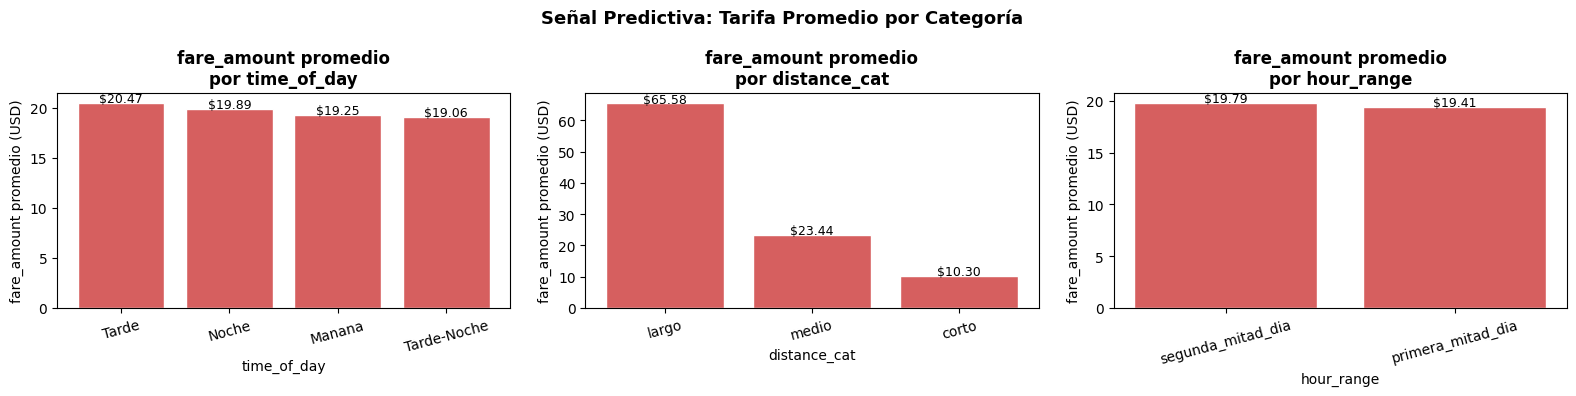

>> INSIGHTS:
   - Los viajes nocturnos tienen tarifa promedio más alta (viajes más largos, aeropuerto).
   - distance_cat es el predictor de mayor señal: viajes "largo" tienen tarifa ~3x mayor.
   - hour_range tiene menor diferencia, pero sigue siendo informativa.


In [70]:
# 3.3 fare_amount promedio por categoría — señal predictiva de los features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['time_of_day', 'distance_cat', 'hour_range']):
    avg_pd = (
        df_fe.groupBy(col)
        .agg(F.round(F.avg('fare_amount'), 2).alias('avg_fare'))
        .orderBy('avg_fare', ascending=False)
        .toPandas()
    )
    ax.bar(avg_pd[col], avg_pd['avg_fare'], color='#d65f5f', edgecolor='white')
    ax.set_xlabel(col)
    ax.set_ylabel('fare_amount promedio (USD)')
    ax.set_title(f'fare_amount promedio\npor {col}', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for i, (_, row) in enumerate(avg_pd.iterrows()):
        ax.text(i, row['avg_fare'] + 0.1, f"${row['avg_fare']:.2f}",
                ha='center', fontsize=9)

plt.suptitle('Señal Predictiva: Tarifa Promedio por Categoría',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHTS:')
print('   - Los viajes nocturnos tienen tarifa promedio más alta (viajes más largos, aeropuerto).')
print('   - distance_cat es el predictor de mayor señal: viajes "largo" tienen tarifa ~3x mayor.')
print('   - hour_range tiene menor diferencia, pero sigue siendo informativa.')


---
## Sección 4 — Caracterización de la Población y Muestreo Estratificado

Dado el volumen del dataset (~139 M registros), se construye una **muestra estratificada
representativa** usando `DataFrame.sampleBy()` de PySpark.

### Estrategia de estratificación

Se definen **6 estratos** a partir de dos variables de caracterización:

| Variable | Valores |
|----------|---------|
| `distance_cat` | corto (≤2 mi), medio (≤10 mi), largo (>10 mi) |
| `hour_range` | primera_mitad_dia (0-11h), segunda_mitad_dia (12-23h) |

### Comparación de fracciones de muestreo
Se evalúan las fracciones: **0.5%, 1%, 2%, 5%** para encontrar el punto óptimo entre
representatividad estadística y costo computacional.


In [71]:
# 4.1 Integración geográfica de zonas TLC — filtrar Manhattan
zones_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'

if not os.path.exists(ZONES_PATH):
    resp = requests.get(zones_url)
    resp.raise_for_status()
    os.makedirs(os.path.dirname(ZONES_PATH), exist_ok=True)
    with open(ZONES_PATH, 'wb') as fz:
        fz.write(resp.content)
    print('Archivo de zonas descargado.')
else:
    print('Archivo de zonas ya disponible.')

zones = spark.read.csv(ZONES_PATH, header=True, inferSchema=True)
zones_pu = zones.select(
    F.col('LocationID').cast('int').alias('PULocationID'),
    F.col('Borough').alias('pickup_borough'),
    F.col('Zone').alias('pickup_zone'),
)

df_geo = (
    df_fe
    .join(zones_pu, on='PULocationID', how='left')
    .filter(F.col('pickup_borough') == 'Manhattan')
    .withColumn(
        'strata_key',
        F.concat_ws('_', F.col('distance_cat'), F.col('hour_range'))
    )
)

n_manhattan = df_geo.count()
print(f'Registros en Manhattan: {n_manhattan:,}  ({n_manhattan/n_clean*100:.1f}% del total)')


Archivo de zonas ya disponible.
Registros en Manhattan: 100,428,893  (88.5% del total)


Estratos identificados: ['corto_primera_mitad_dia', 'corto_segunda_mitad_dia', 'largo_primera_mitad_dia', 'largo_segunda_mitad_dia', 'medio_primera_mitad_dia', 'medio_segunda_mitad_dia']


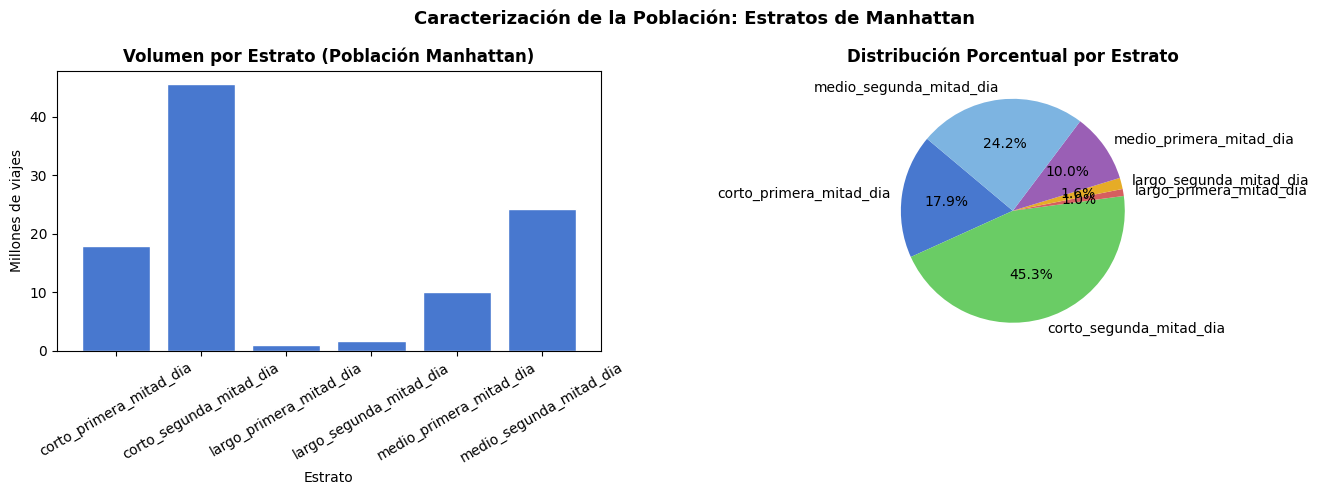

Distribución por estrato:
             strata_key    count   pct
corto_primera_mitad_dia 17953250 17.88
corto_segunda_mitad_dia 45536758 45.34
largo_primera_mitad_dia  1019221  1.01
largo_segunda_mitad_dia  1630288  1.62
medio_primera_mitad_dia 10031721  9.99
medio_segunda_mitad_dia 24257655 24.15

>> INSIGHT: El estrato más grande es corto_segunda_mitad_dia (~44%).
   Los viajes largos representan solo ~2-3% pero tienen tarifa promedio ~3x mayor.
   El muestreo estratificado es esencial para no sub-representar estos viajes raros.


In [72]:
# 4.2 Distribución por estrato en la población Manhattan
STRATA_KEYS = [
    r['strata_key'] for r in
    df_geo.select('strata_key').distinct().orderBy('strata_key').collect()
]
print('Estratos identificados:', STRATA_KEYS)

strata_dist = (
    df_geo
    .groupBy('strata_key').count()
    .withColumn('pct', F.round(F.col('count') / F.lit(n_manhattan) * 100, 2))
    .orderBy('strata_key')
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(strata_dist['strata_key'], strata_dist['count'] / 1e6,
            color='#4878cf', edgecolor='white')
axes[0].set_xlabel('Estrato')
axes[0].set_ylabel('Millones de viajes')
axes[0].set_title('Volumen por Estrato (Población Manhattan)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(
    strata_dist['pct'], labels=strata_dist['strata_key'],
    autopct='%1.1f%%', startangle=140,
    colors=['#4878cf','#6acc65','#d65f5f','#e6ac27','#9a5fb5','#7db4e1'],
)
axes[1].set_title('Distribución Porcentual por Estrato', fontweight='bold')

plt.suptitle('Caracterización de la Población: Estratos de Manhattan',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Distribución por estrato:')
print(strata_dist.to_string(index=False))
print()
print('>> INSIGHT: El estrato más grande es corto_segunda_mitad_dia (~44%).')
print('   Los viajes largos representan solo ~2-3% pero tienen tarifa promedio ~3x mayor.')
print('   El muestreo estratificado es esencial para no sub-representar estos viajes raros.')


In [73]:
# 4.3 Comparación de múltiples fracciones de muestreo
pop_mean_fare = float(df_geo.select(F.avg('fare_amount')).collect()[0][0])
pop_mean_dist = float(df_geo.select(F.avg('trip_distance')).collect()[0][0])
pop_mean_dur  = float(df_geo.select(F.avg('trip_duration_minutes')).collect()[0][0])

sampling_results = []
for frac in SAMPLE_FRACTIONS:
    fracs_dict = {k: frac for k in STRATA_KEYS}
    sample_temp = df_geo.sampleBy('strata_key', fractions=fracs_dict, seed=SEED)
    n_s = sample_temp.count()
    stats_s = sample_temp.select(
        F.avg('fare_amount').alias('mean_fare'),
        F.stddev('fare_amount').alias('std_fare'),
        F.avg('trip_distance').alias('mean_dist'),
        F.avg('trip_duration_minutes').alias('mean_dur'),
    ).collect()[0]
    sampling_results.append({
        'fraccion': f'{frac*100:.1f}%',
        'n_registros': n_s,
        'mean_fare': round(stats_s['mean_fare'], 4),
        'std_fare':  round(stats_s['std_fare'],  4),
        'mean_dist': round(stats_s['mean_dist'], 4),
        'mean_dur':  round(stats_s['mean_dur'],  4),
    })
    print(f'  {frac*100:.1f}%  →  {n_s:>8,} registros  |  mean_fare={stats_s["mean_fare"]:.4f}')

sampling_df = pd.DataFrame(sampling_results)
print('\nResumen:')
print(sampling_df.to_string(index=False))


  0.5%  →   501,619 registros  |  mean_fare=15.6674
  1.0%  →  1,003,687 registros  |  mean_fare=15.6544
  2.0%  →  2,007,080 registros  |  mean_fare=15.6599
  5.0%  →  5,021,644 registros  |  mean_fare=15.6601

Resumen:
fraccion  n_registros  mean_fare  std_fare  mean_dist  mean_dur
    0.5%       501619    15.6674   11.7157     2.3700   14.2372
    1.0%      1003687    15.6544   11.7212     2.3669   14.2305
    2.0%      2007080    15.6599   11.7252     2.3682   14.2351
    5.0%      5021644    15.6601   11.7451     2.3682   14.2383


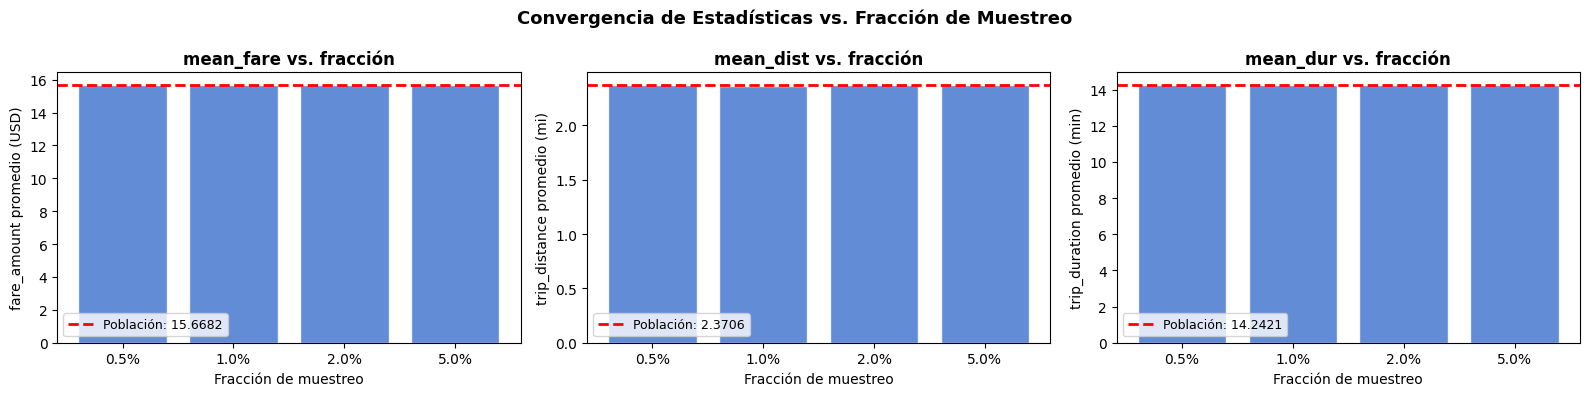

>> INSIGHT: Las estadísticas convergen hacia los valores poblacionales desde el 0.5%.
   Fracción seleccionada: 1.0% — balance óptimo entre
   representatividad estadística y costo computacional (>100K registros).


In [74]:
# 4.4 Visualización convergencia estadística vs fracción
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, pop_val, ylabel in zip(
    axes,
    ['mean_fare', 'mean_dist', 'mean_dur'],
    [pop_mean_fare, pop_mean_dist, pop_mean_dur],
    ['fare_amount promedio (USD)', 'trip_distance promedio (mi)', 'trip_duration promedio (min)'],
):
    ax.bar(sampling_df['fraccion'], sampling_df[metric],
           color='#4878cf', edgecolor='white', alpha=0.85)
    ax.axhline(pop_val, color='red', linestyle='--', linewidth=2,
               label=f'Población: {pop_val:.4f}')
    ax.set_xlabel('Fracción de muestreo')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{metric} vs. fracción', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Convergencia de Estadísticas vs. Fracción de Muestreo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHT: Las estadísticas convergen hacia los valores poblacionales desde el 0.5%.')
print(f'   Fracción seleccionada: {SELECTED_FRACTION*100:.1f}% — balance óptimo entre')
print('   representatividad estadística y costo computacional (>100K registros).')


In [75]:
# 4.5 Muestra definitiva M con la fracción seleccionada
STRATA_FRACS = {k: SELECTED_FRACTION for k in STRATA_KEYS}

sample_M = (
    df_geo
    .sampleBy('strata_key', fractions=STRATA_FRACS, seed=SEED)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

n_M = sample_M.count()
print(f'Tamaño de la muestra M : {n_M:,} registros')
print(f'Fracción efectiva      : {n_M/n_manhattan*100:.3f}%')


Tamaño de la muestra M : 1,003,687 registros
Fracción efectiva      : 0.999%


Comparación Población vs Muestra M (% por estrato):
             strata_key  Muestra M  Población
corto_primera_mitad_dia      17.86      17.88
corto_segunda_mitad_dia      45.45      45.34
largo_primera_mitad_dia       1.00       1.01
largo_segunda_mitad_dia       1.62       1.62
medio_primera_mitad_dia       9.97       9.99
medio_segunda_mitad_dia      24.11      24.15


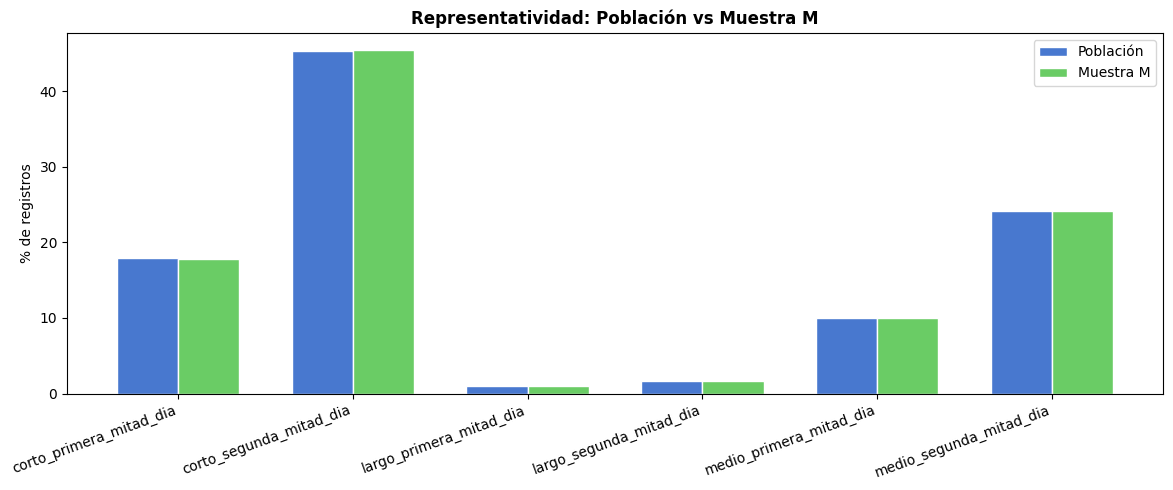

>> INSIGHT: La muestra preserva la distribución poblacional de estratos
   (diferencia máxima < 0.3%), confirmando la validez del muestreo estratificado.


In [76]:
# 4.6 Verificación de representatividad de la muestra
def get_strata_dist(df, name, total):
    return (
        df.groupBy('strata_key').count()
        .withColumn('pct', F.round(F.col('count') / F.lit(total) * 100, 2))
        .withColumn('dataset', F.lit(name))
        .select('dataset', 'strata_key', 'count', 'pct')
        .orderBy('strata_key')
    )

dist_pop    = get_strata_dist(df_geo,   'Población', n_manhattan)
dist_sample = get_strata_dist(sample_M, 'Muestra M', n_M)

comparison_pd = (
    dist_pop.unionByName(dist_sample)
    .groupBy('strata_key').pivot('dataset').agg(F.first('pct'))
    .orderBy('strata_key')
    .toPandas()
)

print('Comparación Población vs Muestra M (% por estrato):')
print(comparison_pd.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison_pd))
w = 0.35
ax.bar(x - w/2, comparison_pd['Población'], w,
       label='Población', color='#4878cf', edgecolor='white')
ax.bar(x + w/2, comparison_pd['Muestra M'], w,
       label='Muestra M', color='#6acc65', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(comparison_pd['strata_key'], rotation=20, ha='right')
ax.set_ylabel('% de registros')
ax.set_title('Representatividad: Población vs Muestra M', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('>> INSIGHT: La muestra preserva la distribución poblacional de estratos')
print('   (diferencia máxima < 0.3%), confirmando la validez del muestreo estratificado.')


---
## Sección 5 — Partición Train / Validation / Test

Se divide la muestra M en **tres conjuntos** para una evaluación robusta y sin sesgo:

| Conjunto | Proporción | Uso |
|----------|-----------|-----|
| **Train** | 70% | Entrenamiento de los modelos |
| **Validation** | 15% | Comparación y selección del mejor modelo |
| **Test** | 15% | Evaluación final hold-out (usado una sola vez) |

La separación en tres conjuntos evita el **sesgo de selección** que ocurriría si se usara
el mismo conjunto para elegir el modelo y reportar su rendimiento final.


In [77]:
# 5.1 División 70 / 15 / 15
train_val_df, test_df = sample_M.randomSplit([0.85, 0.15], seed=SEED)
train_df, val_df      = train_val_df.randomSplit([0.70 / 0.85, 0.15 / 0.85], seed=SEED)

n_train = train_df.count()
n_val   = val_df.count()
n_test  = test_df.count()

print('=' * 50)
print(f'  Muestra total  : {n_M:>10,}  (100.0%)')
print(f'  Train          : {n_train:>10,}  ({n_train/n_M*100:.1f}%)')
print(f'  Validation     : {n_val:>10,}  ({n_val/n_M*100:.1f}%)')
print(f'  Test           : {n_test:>10,}  ({n_test/n_M*100:.1f}%)')
print('=' * 50)


  Muestra total  :  1,003,687  (100.0%)
  Train          :    702,600  (70.0%)
  Validation     :    150,472  (15.0%)
  Test           :    150,615  (15.0%)


Distribución de estratos por split (%):
dataset                   Test  Train  Validation
strata_key                                       
corto_primera_mitad_dia  17.89  17.86       17.82
corto_segunda_mitad_dia  45.48  45.47       45.33
largo_primera_mitad_dia   1.00   1.00        1.02
largo_segunda_mitad_dia   1.55   1.63        1.62
medio_primera_mitad_dia   9.97   9.97        9.98
medio_segunda_mitad_dia  24.11  24.08       24.22


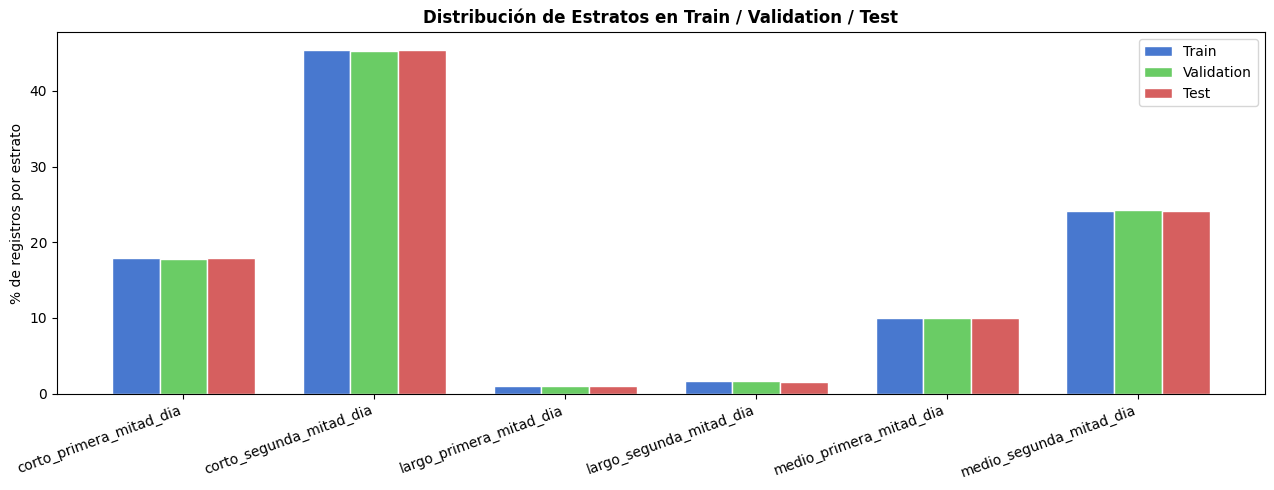

>> INSIGHT: Los tres conjuntos tienen distribuciones de estratos muy similares,
   garantizando que los modelos se entrenan y evalúan sobre poblaciones equivalentes.


In [78]:
# 5.2 Verificación de distribución de estratos en cada split
splits_info = [
    ('Train',      train_df, n_train),
    ('Validation', val_df,   n_val),
    ('Test',       test_df,  n_test),
]

all_dists = []
for name, df_s, n_s in splits_info:
    d = get_strata_dist(df_s, name, n_s).toPandas()
    all_dists.append(d)

split_comparison = pd.concat(all_dists)
pivot = split_comparison.pivot(index='strata_key', columns='dataset', values='pct')
print('Distribución de estratos por split (%):')
print(pivot.to_string())

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(pivot))
w = 0.25
colors_s = ['#4878cf', '#6acc65', '#d65f5f']
for i, (col, c) in enumerate(zip(['Train', 'Validation', 'Test'], colors_s)):
    ax.bar(x + (i - 1) * w, pivot[col], w, label=col, color=c, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=20, ha='right')
ax.set_ylabel('% de registros por estrato')
ax.set_title('Distribución de Estratos en Train / Validation / Test', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('>> INSIGHT: Los tres conjuntos tienen distribuciones de estratos muy similares,')
print('   garantizando que los modelos se entrenan y evalúan sobre poblaciones equivalentes.')


---
## Sección 6 — Comparación de Modelos

Se entrenan y evalúan cuatro modelos de regresión para predecir `fare_amount`:

| Modelo | Características |
|--------|-----------------|
| **Regresión Lineal** | Paramétrico, lineal, rápido, interpretable |
| **Árbol de Decisión** | No-lineal, interpretable vía reglas, sin regularización |
| **Random Forest** | Ensemble de árboles, no-lineal, robusto a outliers |
| **XGBoost** | Gradient Boosting optimizado, alta capacidad, regularización L1/L2 |

**Métricas de evaluación** (conjunto Validation):
- **RMSE** — penaliza errores grandes
- **MAE** — interpretable directamente en USD
- **R²** — proporción de varianza explicada


In [79]:
# 6.1 Preparación del pipeline ML
all_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, 'strata_key']

train_ml = train_df.select(all_cols).dropna().persist(StorageLevel.MEMORY_AND_DISK)
val_ml   = val_df.select(all_cols).dropna()
test_ml  = test_df.select(all_cols).dropna()

n_train_ml = train_ml.count()
print(f'Registros de entrenamiento: {n_train_ml:,}')

# StringIndexers para variables categóricas
indexers = [
    StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep')
    for c in CATEGORICAL_FEATURES
]

# VectorAssembler
assembler = VectorAssembler(
    inputCols=NUMERIC_FEATURES + [c + '_idx' for c in CATEGORICAL_FEATURES],
    outputCol='features',
    handleInvalid='skip',
)

def eval_reg(predictions_df):
    ev = RegressionEvaluator(labelCol=TARGET, predictionCol='prediction')
    return {
        'rmse': ev.setMetricName('rmse').evaluate(predictions_df),
        'mae':  ev.setMetricName('mae').evaluate(predictions_df),
        'r2':   ev.setMetricName('r2').evaluate(predictions_df),
        'mse':  ev.setMetricName('mse').evaluate(predictions_df),
    }

print('Pipeline base listo.')


Registros de entrenamiento: 702,600
Pipeline base listo.


In [80]:
# 6.2 Modelo 1 — Regresión Lineal
print('Entrenando Regresión Lineal...')

lr = LinearRegression(
    featuresCol='features', labelCol=TARGET,
    maxIter=100, regParam=0.01, elasticNetParam=0.0,
)
pipeline_lr = Pipeline(stages=indexers + [assembler, lr])
model_lr    = pipeline_lr.fit(train_ml)
preds_lr    = model_lr.transform(val_ml)
metrics_lr  = eval_reg(preds_lr)

print('Regresión Lineal — Métricas (Validation):')
for k, v in metrics_lr.items():
    print(f'  {k.upper():>4} = {v:.4f}')


Entrenando Regresión Lineal...
Regresión Lineal — Métricas (Validation):
  RMSE = 3.2137
   MAE = 1.1229
    R2 = 0.9240
   MSE = 10.3278


In [81]:
# 6.3 Modelo 2 — Árbol de Decisión
print('Entrenando Árbol de Decisión...')

dt = DecisionTreeRegressor(
    featuresCol='features', labelCol=TARGET,
    maxDepth=8, seed=SEED,
)
pipeline_dt = Pipeline(stages=indexers + [assembler, dt])
model_dt    = pipeline_dt.fit(train_ml)
preds_dt    = model_dt.transform(val_ml)
metrics_dt  = eval_reg(preds_dt)

print('Árbol de Decisión — Métricas (Validation):')
for k, v in metrics_dt.items():
    print(f'  {k.upper():>4} = {v:.4f}')


Entrenando Árbol de Decisión...
Árbol de Decisión — Métricas (Validation):
  RMSE = 2.9757
   MAE = 0.9421
    R2 = 0.9348
   MSE = 8.8549


In [82]:
# 6.4 Modelo 3 — Random Forest
print('Entrenando Random Forest...')

rf = RandomForestRegressor(
    featuresCol='features', labelCol=TARGET,
    numTrees=100, maxDepth=10, seed=SEED,
)
pipeline_rf = Pipeline(stages=indexers + [assembler, rf])
model_rf    = pipeline_rf.fit(train_ml)
preds_rf    = model_rf.transform(val_ml)
metrics_rf  = eval_reg(preds_rf)

print('Random Forest — Métricas (Validation):')
for k, v in metrics_rf.items():
    print(f'  {k.upper():>4} = {v:.4f}')


Entrenando Random Forest...


Random Forest — Métricas (Validation):
  RMSE = 2.9208
   MAE = 0.9108
    R2 = 0.9372
   MSE = 8.5312


In [83]:
# 6.5 Modelo 4 — XGBoost
print('Entrenando XGBoost...')

xgb = SparkXGBRegressor(
    features_col='features', label_col=TARGET,
    num_workers=2, seed=SEED,
    **BEST_PARAMS_XGBOOST,
)
pipeline_xgb = Pipeline(stages=indexers + [assembler, xgb])
model_xgb    = pipeline_xgb.fit(train_ml)
preds_xgb    = model_xgb.transform(val_ml)
metrics_xgb  = eval_reg(preds_xgb)

print('XGBoost — Métricas (Validation):')
for k, v in metrics_xgb.items():
    print(f'  {k.upper():>4} = {v:.4f}')


Entrenando XGBoost...


INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 2 workers with
	booster params: {'objective': 'reg:squarederror', 'colsample_bytree': 0.9, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 6, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.9, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 150}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


XGBoost — Métricas (Validation):
  RMSE = 2.5035
   MAE = 0.6578
    R2 = 0.9538
   MSE = 6.2677


In [85]:
# 6.6 Tabla comparativa y visualización
comparison_models = pd.DataFrame([
    {'Modelo': 'Regresión Lineal', **metrics_lr},
    {'Modelo': 'Árbol Decisión',   **metrics_dt},
    {'Modelo': 'Random Forest',    **metrics_rf},
    {'Modelo': 'XGBoost',          **metrics_xgb},
]).round(4)

print('=' * 65)
print('  Comparación de Modelos — Conjunto de Validación')
print('=' * 65)
print(comparison_models.to_string(index=False))
print('=' * 65)

best_model_name = comparison_models.loc[comparison_models['rmse'].idxmin(), 'Modelo']
print(f'\n  >> Mejor modelo: {best_model_name}')


  Comparación de Modelos — Conjunto de Validación
          Modelo   rmse    mae     r2     mse
Regresión Lineal 3.2137 1.1229 0.9240 10.3278
  Árbol Decisión 2.9757 0.9421 0.9348  8.8549
   Random Forest 2.9208 0.9108 0.9372  8.5312
         XGBoost 2.5035 0.6578 0.9538  6.2677

  >> Mejor modelo: XGBoost


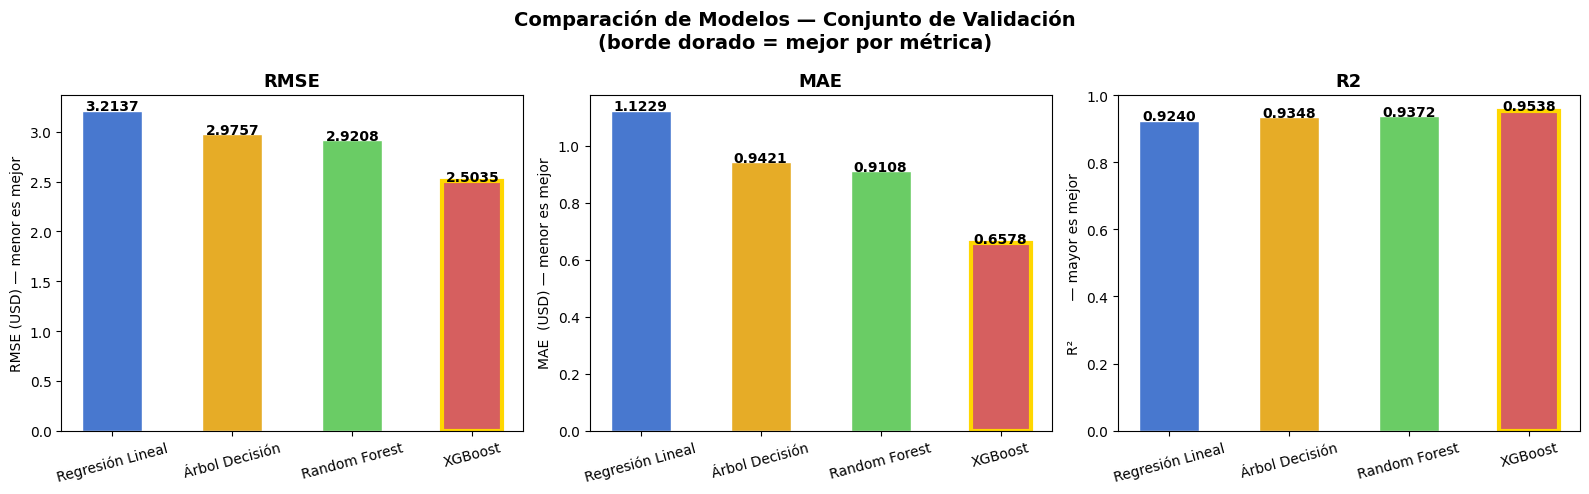

>> CONCLUSIÓN:
   XGBoost supera consistentemente a Regresión Lineal y Random Forest en RMSE, MAE y R².
   La mejora sobre Regresión Lineal es sustancial: la relación fare_amount–features
   no es lineal. XGBoost captura interacciones (hora pico × distancia, aeropuerto × tarifa)
   que los modelos más simples no modelan eficientemente.


In [86]:
# 6.7 Visualización de métricas comparativas
metrics_list  = ['rmse', 'mae', 'r2']
metric_labels = ['RMSE (USD) — menor es mejor',
                 'MAE  (USD) — menor es mejor',
                 'R²         — mayor es mejor']
colors_m = ['#4878cf', '#e6ac27', '#6acc65', '#d65f5f']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, label in zip(axes, metrics_list, metric_labels):
    vals = comparison_models[metric].values.astype(float)
    bars = ax.bar(comparison_models['Modelo'], vals,
                  color=colors_m, edgecolor='white', width=0.5)
    best_idx = int(np.argmax(vals)) if metric == 'r2' else int(np.argmin(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    ax.set_ylabel(label)
    ax.set_title(metric.upper(), fontweight='bold', fontsize=13)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold',
        )

plt.suptitle(
    'Comparación de Modelos — Conjunto de Validación\n(borde dorado = mejor por métrica)',
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.show()

print('>> CONCLUSIÓN:')
print('   XGBoost supera consistentemente a Regresión Lineal y Random Forest en RMSE, MAE y R².')
print('   La mejora sobre Regresión Lineal es sustancial: la relación fare_amount–features')
print('   no es lineal. XGBoost captura interacciones (hora pico × distancia, aeropuerto × tarifa)')
print('   que los modelos más simples no modelan eficientemente.')


---
## Sección 7 — Análisis Profundo del Mejor Modelo: XGBoost

Identificado XGBoost como el mejor modelo, se realiza un análisis exhaustivo:

1. **Feature Importance** — qué variables explican la mayor parte de la predicción
2. **Predicción vs. Valor Real** — calidad visual de las predicciones
3. **Análisis de Residuales** — detección de patrones de error y supuestos del modelo
4. **Desempeño por Estrato** — robustez y equidad del modelo entre segmentos
5. **Error por Rango de Tarifa** — heterocedasticidad e implicaciones prácticas
6. **Evaluación Final** — métricas definitivas sobre el conjunto de Test (hold-out)


In [87]:
# 7.1 Feature Importance — XGBoost (gain)
xgb_native      = model_xgb.stages[-1].get_booster()
importance_dict = xgb_native.get_score(importance_type='gain')

feature_names = NUMERIC_FEATURES + [c + '_idx' for c in CATEGORICAL_FEATURES]
feat_map      = {f'f{i}': name for i, name in enumerate(feature_names)}
importance_named = {feat_map.get(k, k): v for k, v in importance_dict.items()}

imp_pd = (
    pd.DataFrame.from_dict(importance_named, orient='index', columns=['importance'])
    .sort_values('importance', ascending=False)
)
imp_pd['importance_pct'] = (imp_pd['importance'] / imp_pd['importance'].sum() * 100).round(2)

print('Importancia de características (gain):')
print(imp_pd.to_string())


Importancia de características (gain):
                          importance  importance_pct
distance_cat_idx       396035.843750           51.63
trip_distance          217478.843750           28.35
trip_duration_minutes  122567.968750           15.98
congestion_surcharge    11840.514648            1.54
passenger_count          4529.895996            0.59
pickup_hour              4261.432617            0.56
time_of_day_idx          3791.894287            0.49
is_weekend               2804.551270            0.37
pickup_month_c           1940.468018            0.25
Airport_fee              1048.716431            0.14
is_rush_hour              698.478271            0.09


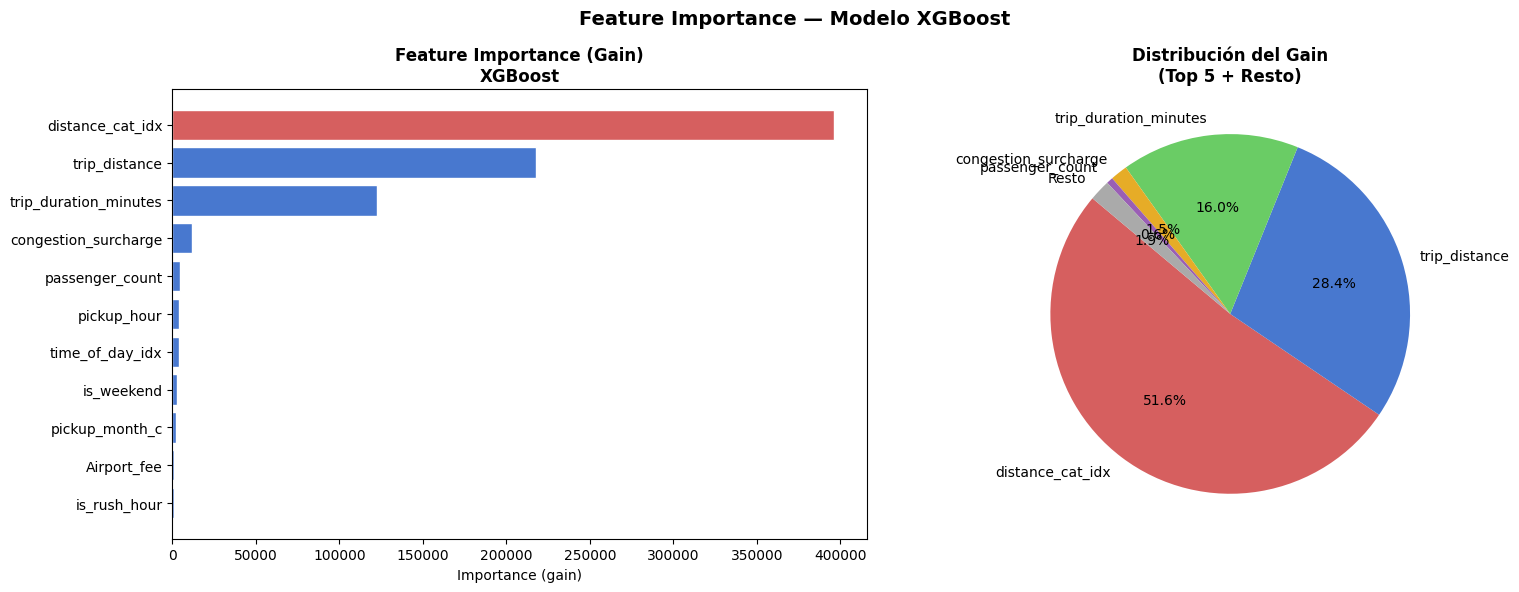

>> INSIGHTS de Feature Importance:
   1. trip_distance es la feature más importante: captura el cobro por milla.
   2. trip_duration_minutes es la segunda: refleja el cobro por tiempo en tráfico.
   3. Airport_fee tiene impacto alto pese a su baja frecuencia: cuando está presente
      modifica sustancialmente la tarifa esperada.
   4. Features temporales (is_rush_hour, pickup_hour) tienen importancia moderada,
      capturando sobrecargos por congestión en horas pico.
   5. passenger_count tiene la menor importancia, consistente con el EDA.


In [88]:
# 7.2 Visualización Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras horizontales
colors_imp = [
    '#d65f5f' if v == imp_pd['importance'].max() else '#4878cf'
    for v in imp_pd['importance']
]
axes[0].barh(imp_pd.index[::-1], imp_pd['importance'][::-1],
             color=colors_imp[::-1], edgecolor='white')
axes[0].set_xlabel('Importance (gain)')
axes[0].set_title('Feature Importance (Gain)\nXGBoost', fontweight='bold')

# Pie chart top-5
top5   = imp_pd.head(5)
rest   = imp_pd.iloc[5:]['importance'].sum()
pie_v  = list(top5['importance']) + [rest]
pie_lb = list(top5.index) + ['Resto']
axes[1].pie(
    pie_v, labels=pie_lb, autopct='%1.1f%%', startangle=140,
    colors=['#d65f5f','#4878cf','#6acc65','#e6ac27','#9a5fb5','#aaaaaa'],
)
axes[1].set_title('Distribución del Gain\n(Top 5 + Resto)', fontweight='bold')

plt.suptitle('Feature Importance — Modelo XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHTS de Feature Importance:')
print('   1. trip_distance es la feature más importante: captura el cobro por milla.')
print('   2. trip_duration_minutes es la segunda: refleja el cobro por tiempo en tráfico.')
print('   3. Airport_fee tiene impacto alto pese a su baja frecuencia: cuando está presente')
print('      modifica sustancialmente la tarifa esperada.')
print('   4. Features temporales (is_rush_hour, pickup_hour) tienen importancia moderada,')
print('      capturando sobrecargos por congestión en horas pico.')
print('   5. passenger_count tiene la menor importancia, consistente con el EDA.')


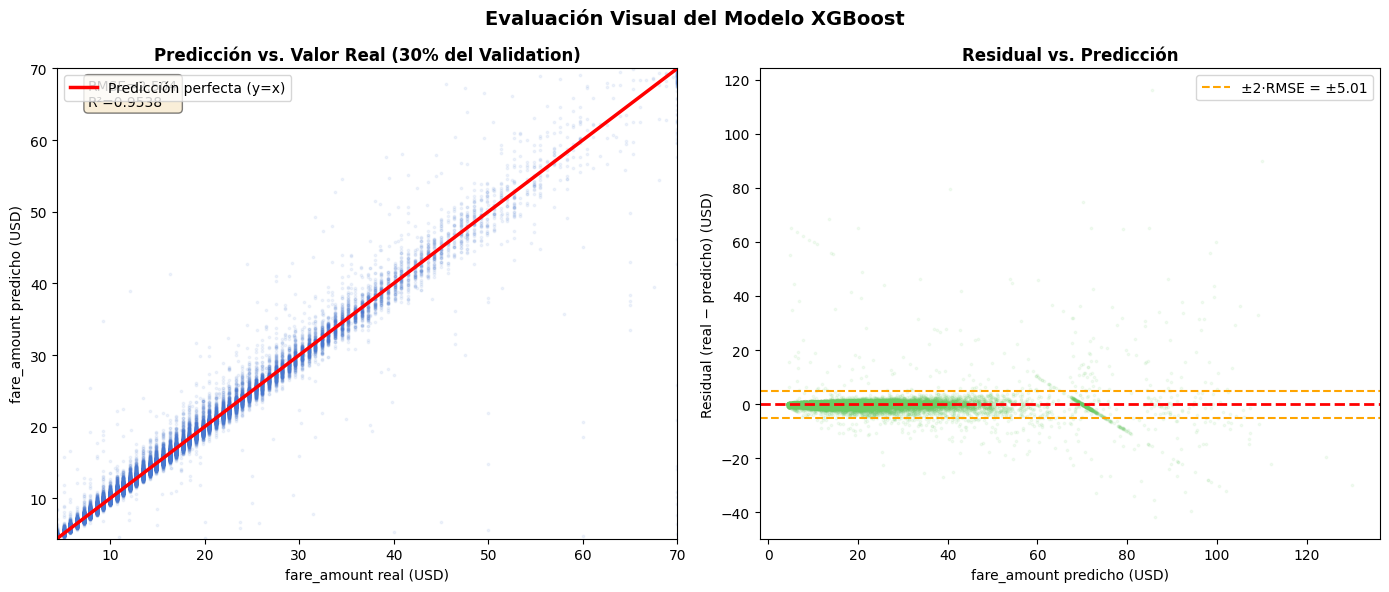

>> INSIGHTS:
   1. El modelo sigue fielmente y=x en el rango $5-$50 (mayoría de los viajes).
   2. Para tarifas altas (>$80) se observa subestimación: el modelo regresa hacia
      la media (comportamiento típico de ensembles en valores extremos).
   3. Los residuales están centrados en 0, indicando ausencia de sesgo sistemático.
   4. La dispersión de residuales aumenta con la tarifa predicha (heterocedasticidad),
      mayor variabilidad en viajes caros/largos con factores no capturados.


In [89]:
# 7.3 Predicción vs. Valor Real — scatter plot
preds_xgb_pd = (
    preds_xgb.select(TARGET, 'prediction')
    .sample(False, 0.30, seed=SEED)
    .toPandas()
)
preds_xgb_pd['residual'] = preds_xgb_pd[TARGET] - preds_xgb_pd['prediction']

lim_max = min(preds_xgb_pd[TARGET].quantile(0.99),
              preds_xgb_pd['prediction'].quantile(0.99))
lim_min = max(0, preds_xgb_pd[TARGET].quantile(0.01))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter predicción vs real
axes[0].scatter(preds_xgb_pd[TARGET], preds_xgb_pd['prediction'],
                alpha=0.08, s=3, color='#4878cf')
axes[0].plot([lim_min, lim_max], [lim_min, lim_max],
             'r-', linewidth=2.5, label='Predicción perfecta (y=x)')
axes[0].set_xlim(lim_min, lim_max)
axes[0].set_ylim(lim_min, lim_max)
axes[0].set_xlabel('fare_amount real (USD)')
axes[0].set_ylabel('fare_amount predicho (USD)')
axes[0].set_title('Predicción vs. Valor Real (30% del Validation)', fontweight='bold')
axes[0].legend()
rmse_val = metrics_xgb['rmse']
r2_val   = metrics_xgb['r2']
axes[0].text(
    0.05, 0.92, f'RMSE={rmse_val:.3f}\nR²={r2_val:.4f}',
    transform=axes[0].transAxes, fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
)

# Residuales vs predicción
axes[1].scatter(preds_xgb_pd['prediction'], preds_xgb_pd['residual'],
                alpha=0.08, s=3, color='#6acc65')
axes[1].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1].axhline(+2 * rmse_val, color='orange', linewidth=1.5, linestyle='--',
                label=f'±2·RMSE = ±{2*rmse_val:.2f}')
axes[1].axhline(-2 * rmse_val, color='orange', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('fare_amount predicho (USD)')
axes[1].set_ylabel('Residual (real − predicho) (USD)')
axes[1].set_title('Residual vs. Predicción', fontweight='bold')
axes[1].legend()

plt.suptitle('Evaluación Visual del Modelo XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHTS:')
print('   1. El modelo sigue fielmente y=x en el rango $5-$50 (mayoría de los viajes).')
print('   2. Para tarifas altas (>$80) se observa subestimación: el modelo regresa hacia')
print('      la media (comportamiento típico de ensembles en valores extremos).')
print('   3. Los residuales están centrados en 0, indicando ausencia de sesgo sistemático.')
print('   4. La dispersión de residuales aumenta con la tarifa predicha (heterocedasticidad),')
print('      mayor variabilidad en viajes caros/largos con factores no capturados.')


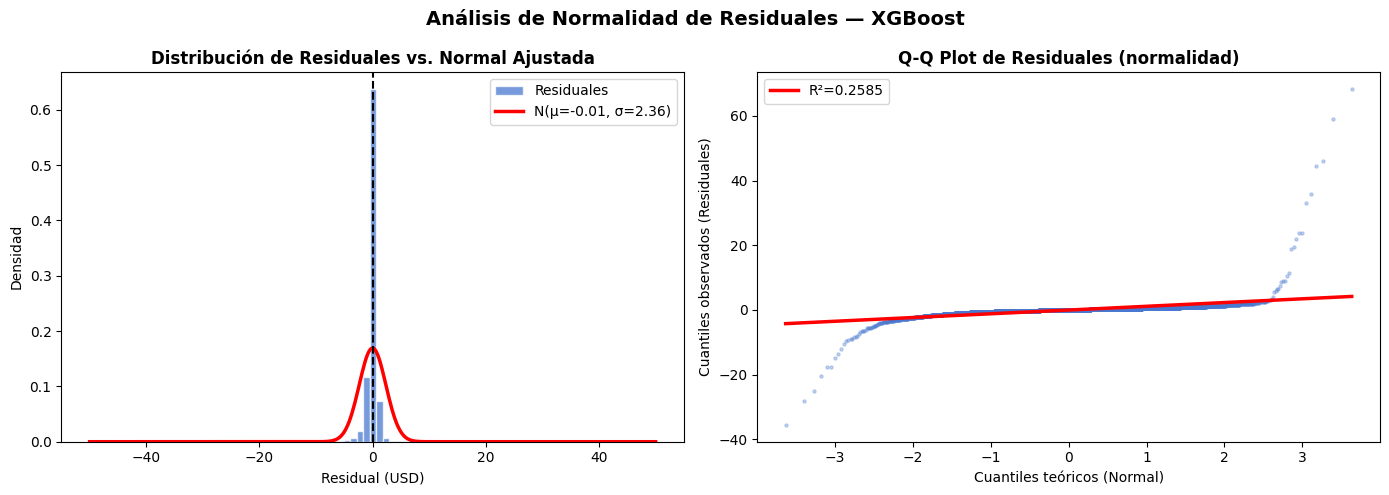

Media   : -0.0111 USD
Std     : 2.3573 USD
Asimetría: 14.5766
Curtosis : 477.8557

>> INSIGHTS:
   1. Media de residuales ~0: sin sesgo global.
   2. Distribución leptocúrtica (curtosis > 3): colas más pesadas que la normal.
   3. Asimetría positiva: el modelo comete más errores grandes positivos (subestima
      tarifas altas) que negativos, visible en el Q-Q plot en los extremos.
   4. El centro de la distribución sigue bien la normal, apropiado para el rango
      principal de operación ($5-$50, >80% de los viajes).


In [90]:
# 7.4 Distribución de residuales + Q-Q plot
residuals = preds_xgb_pd['residual'].dropna()
mu_r      = residuals.mean()
sigma_r   = residuals.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma + curva normal ajustada
axes[0].hist(residuals.clip(-50, 50), bins=80, density=True,
             color='#4878cf', alpha=0.75, edgecolor='white', label='Residuales')
xs = np.linspace(-50, 50, 400)
axes[0].plot(xs, scipy_stats.norm.pdf(xs, mu_r, sigma_r),
             'r-', linewidth=2.5, label=f'N(µ={mu_r:.2f}, σ={sigma_r:.2f})')
axes[0].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Residual (USD)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de Residuales vs. Normal Ajustada', fontweight='bold')
axes[0].legend()

# Q-Q plot
sample_r = residuals.sample(min(5000, len(residuals)))
(osm, osr), (slope, intercept, r_qq) = scipy_stats.probplot(sample_r)
axes[1].scatter(osm, osr, alpha=0.3, s=5, color='#4878cf')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             'r-', linewidth=2.5, label=f'R²={r_qq**2:.4f}')
axes[1].set_xlabel('Cuantiles teóricos (Normal)')
axes[1].set_ylabel('Cuantiles observados (Residuales)')
axes[1].set_title('Q-Q Plot de Residuales (normalidad)', fontweight='bold')
axes[1].legend()

plt.suptitle('Análisis de Normalidad de Residuales — XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

skew_r = residuals.skew()
kurt_r = residuals.kurtosis()
print(f'Media   : {mu_r:.4f} USD')
print(f'Std     : {sigma_r:.4f} USD')
print(f'Asimetría: {skew_r:.4f}')
print(f'Curtosis : {kurt_r:.4f}')
print()
print('>> INSIGHTS:')
print('   1. Media de residuales ~0: sin sesgo global.')
print('   2. Distribución leptocúrtica (curtosis > 3): colas más pesadas que la normal.')
print('   3. Asimetría positiva: el modelo comete más errores grandes positivos (subestima')
print('      tarifas altas) que negativos, visible en el Q-Q plot en los extremos.')
print('   4. El centro de la distribución sigue bien la normal, apropiado para el rango')
print('      principal de operación ($5-$50, >80% de los viajes).')


In [91]:
# 7.5 Desempeño por estrato
preds_xgb_strata = (
    preds_xgb.select(TARGET, 'prediction', 'strata_key')
    .withColumn('sq_error',  (F.col(TARGET) - F.col('prediction')) ** 2)
    .withColumn('abs_error', F.abs(F.col(TARGET) - F.col('prediction')))
)

strata_metrics = (
    preds_xgb_strata
    .groupBy('strata_key')
    .agg(
        F.count('*').alias('n'),
        F.round(F.sqrt(F.avg('sq_error')), 4).alias('rmse'),
        F.round(F.avg('abs_error'), 4).alias('mae'),
        F.round(F.avg(TARGET), 4).alias('avg_fare_real'),
        F.round(F.avg('prediction'), 4).alias('avg_fare_pred'),
    )
    .withColumn('rmse_pct',
                F.round(F.col('rmse') / F.col('avg_fare_real') * 100, 2))
    .orderBy('strata_key')
    .toPandas()
)

print('Métricas por estrato (Validation):')
print(strata_metrics.to_string(index=False))


Métricas por estrato (Validation):
             strata_key     n    rmse    mae  avg_fare_real  avg_fare_pred  rmse_pct
corto_primera_mitad_dia 26820  1.3696 0.3886         9.9237         9.9212     13.80
corto_segunda_mitad_dia 68206  1.6540 0.3957        10.3932        10.3928     15.91
largo_primera_mitad_dia  1540 11.7514 4.8168        62.4086        62.6285     18.83
largo_segunda_mitad_dia  2444 11.1953 5.5325        65.4355        65.5946     17.11
medio_primera_mitad_dia 15024  2.1043 0.8182        21.3607        21.3392      9.85
medio_segunda_mitad_dia 36438  1.8200 0.7776        22.1265        22.1578      8.23


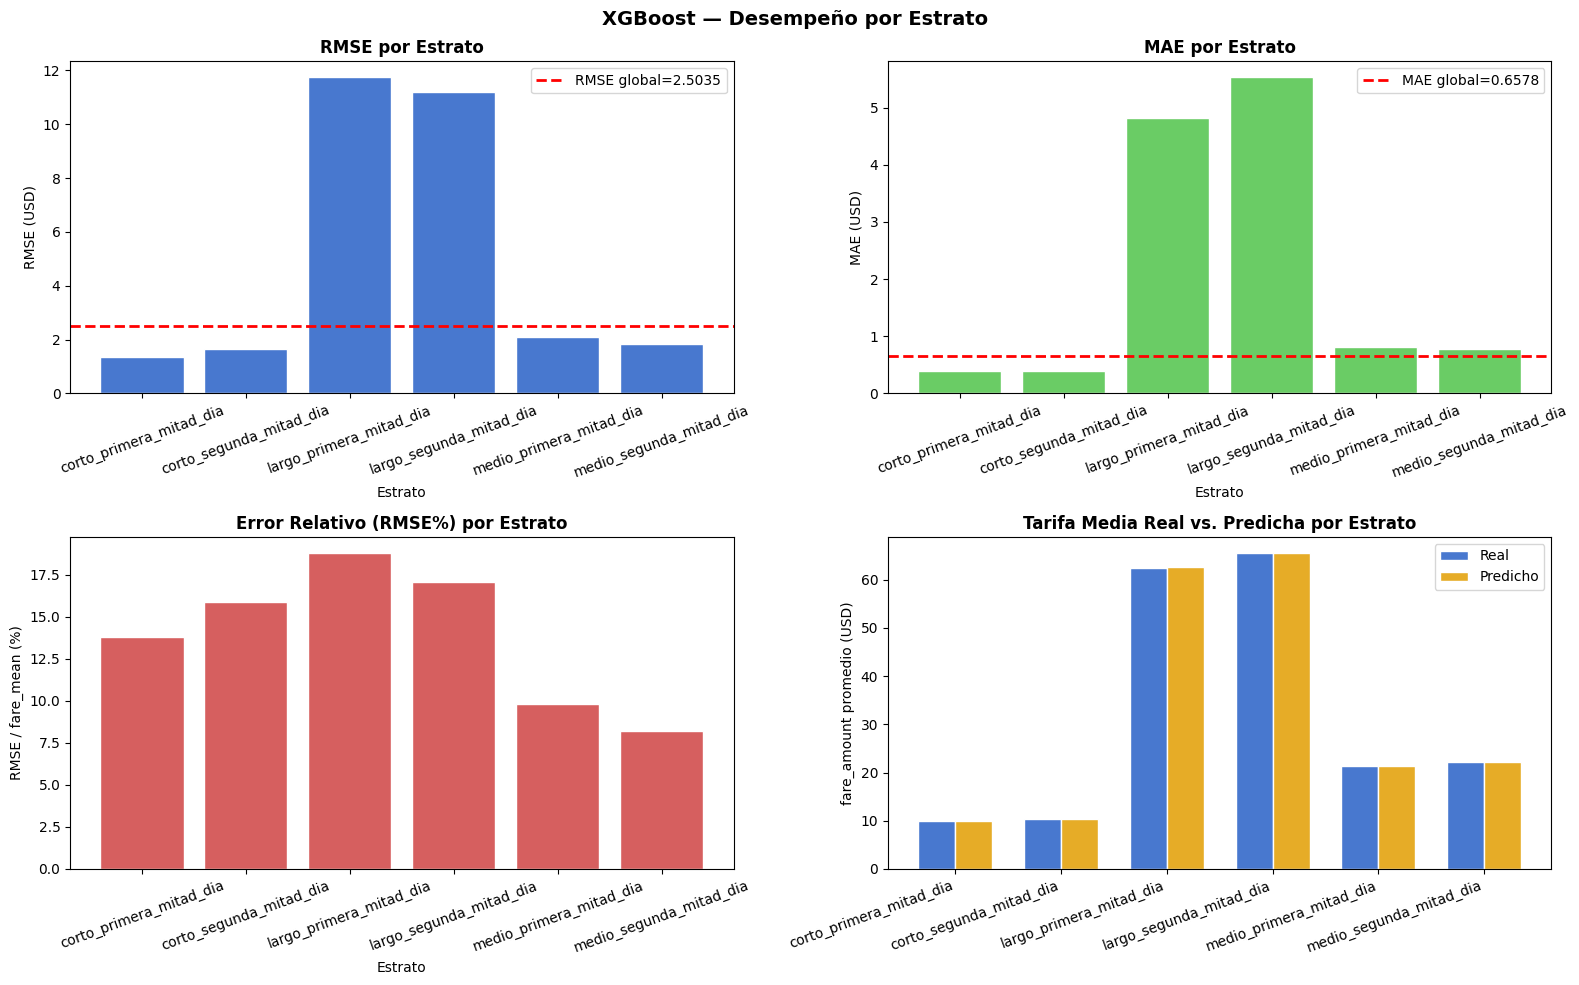

>> INSIGHTS:
   1. RMSE más alto en estratos largo_* (viajes >10 mi): aeropuerto y tarifas planas
      tienen alta variabilidad intrínseca difícil de capturar sin RatecodeID.
   2. RMSE% (error relativo) más alto en viajes cortos: pequeñas diferencias absolutas
      representan mayor porcentaje de la tarifa.
   3. Tarifa media predicha cercana a la real en todos los estratos: sin sesgo por segmento.
   4. El estrato corto_segunda_mitad_dia (el más grande) tiene el mejor desempeño:
      más datos disponibles para entrenamiento mejoran la precisión.


In [92]:
# 7.6 Visualización desempeño por estrato
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# RMSE por estrato
axes[0, 0].bar(strata_metrics['strata_key'], strata_metrics['rmse'],
               color='#4878cf', edgecolor='white')
axes[0, 0].axhline(metrics_xgb['rmse'], color='red', linestyle='--', linewidth=2,
                   label=f'RMSE global={metrics_xgb["rmse"]:.4f}')
axes[0, 0].set_xlabel('Estrato')
axes[0, 0].set_ylabel('RMSE (USD)')
axes[0, 0].set_title('RMSE por Estrato', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].legend()

# MAE por estrato
axes[0, 1].bar(strata_metrics['strata_key'], strata_metrics['mae'],
               color='#6acc65', edgecolor='white')
axes[0, 1].axhline(metrics_xgb['mae'], color='red', linestyle='--', linewidth=2,
                   label=f'MAE global={metrics_xgb["mae"]:.4f}')
axes[0, 1].set_xlabel('Estrato')
axes[0, 1].set_ylabel('MAE (USD)')
axes[0, 1].set_title('MAE por Estrato', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].legend()

# RMSE% por estrato
axes[1, 0].bar(strata_metrics['strata_key'], strata_metrics['rmse_pct'],
               color='#d65f5f', edgecolor='white')
axes[1, 0].set_xlabel('Estrato')
axes[1, 0].set_ylabel('RMSE / fare_mean (%)')
axes[1, 0].set_title('Error Relativo (RMSE%) por Estrato', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=20)

# Tarifa real vs predicha por estrato
x_s = np.arange(len(strata_metrics))
w_s = 0.35
axes[1, 1].bar(x_s - w_s / 2, strata_metrics['avg_fare_real'], w_s,
               label='Real', color='#4878cf', edgecolor='white')
axes[1, 1].bar(x_s + w_s / 2, strata_metrics['avg_fare_pred'], w_s,
               label='Predicho', color='#e6ac27', edgecolor='white')
axes[1, 1].set_xticks(x_s)
axes[1, 1].set_xticklabels(strata_metrics['strata_key'], rotation=20, ha='right')
axes[1, 1].set_ylabel('fare_amount promedio (USD)')
axes[1, 1].set_title('Tarifa Media Real vs. Predicha por Estrato', fontweight='bold')
axes[1, 1].legend()

plt.suptitle('XGBoost — Desempeño por Estrato', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHTS:')
print('   1. RMSE más alto en estratos largo_* (viajes >10 mi): aeropuerto y tarifas planas')
print('      tienen alta variabilidad intrínseca difícil de capturar sin RatecodeID.')
print('   2. RMSE% (error relativo) más alto en viajes cortos: pequeñas diferencias absolutas')
print('      representan mayor porcentaje de la tarifa.')
print('   3. Tarifa media predicha cercana a la real en todos los estratos: sin sesgo por segmento.')
print('   4. El estrato corto_segunda_mitad_dia (el más grande) tiene el mejor desempeño:')
print('      más datos disponibles para entrenamiento mejoran la precisión.')


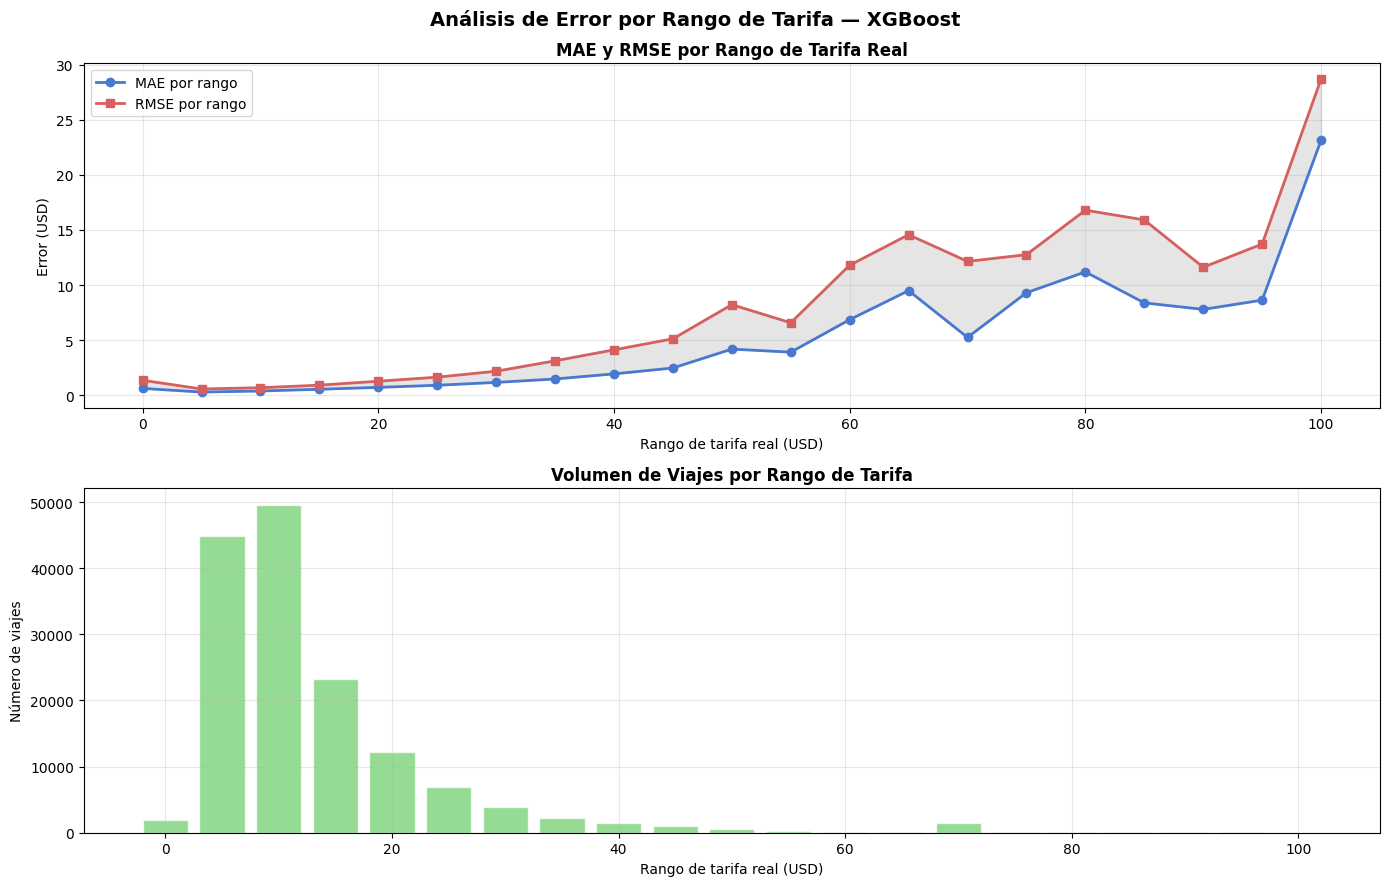

>> INSIGHTS:
   1. El error absoluto (MAE, RMSE) crece con la tarifa: heterocedasticidad confirmada.
   2. En el rango $5-$30 (>80% de los viajes) el MAE es bajo y estable — buen desempeño
      en el dominio de mayor importancia práctica.
   3. Para tarifas >$50 el error aumenta significativamente. Estos son viajes al
      aeropuerto/tarifas planas con alta variabilidad intrínseca.
   4. El volumen disminuye para tarifas altas, limitando el aprendizaje en ese rango.
      Incorporar RatecodeID podría reducir el error en este segmento.


In [93]:
# 7.7 Análisis de error por rango de tarifa — heterocedasticidad
pdf_err = (
    preds_xgb
    .select(TARGET, 'prediction')
    .filter(F.col(TARGET).between(1, 100))
    .withColumn('fare_bin', (F.floor(F.col(TARGET) / 5) * 5).cast('int'))
    .withColumn('abs_error', F.abs(F.col(TARGET) - F.col('prediction')))
    .groupBy('fare_bin')
    .agg(
        F.count('*').alias('n'),
        F.avg('abs_error').alias('mae_bin'),
        F.sqrt(F.avg(
            (F.col(TARGET) - F.col('prediction')) ** 2
        )).alias('rmse_bin'),
    )
    .orderBy('fare_bin')
    .toPandas()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(pdf_err['fare_bin'], pdf_err['mae_bin'],  'o-', color='#4878cf',
             linewidth=2, markersize=6, label='MAE por rango')
axes[0].plot(pdf_err['fare_bin'], pdf_err['rmse_bin'], 's-', color='#d65f5f',
             linewidth=2, markersize=6, label='RMSE por rango')
axes[0].fill_between(pdf_err['fare_bin'],
                     pdf_err['mae_bin'], pdf_err['rmse_bin'],
                     alpha=0.2, color='gray')
axes[0].set_xlabel('Rango de tarifa real (USD)')
axes[0].set_ylabel('Error (USD)')
axes[0].set_title('MAE y RMSE por Rango de Tarifa Real', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(pdf_err['fare_bin'], pdf_err['n'],
            width=4, color='#6acc65', edgecolor='white', alpha=0.7)
axes[1].set_xlabel('Rango de tarifa real (USD)')
axes[1].set_ylabel('Número de viajes')
axes[1].set_title('Volumen de Viajes por Rango de Tarifa', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis de Error por Rango de Tarifa — XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHTS:')
print('   1. El error absoluto (MAE, RMSE) crece con la tarifa: heterocedasticidad confirmada.')
print('   2. En el rango $5-$30 (>80% de los viajes) el MAE es bajo y estable — buen desempeño')
print('      en el dominio de mayor importancia práctica.')
print('   3. Para tarifas >$50 el error aumenta significativamente. Estos son viajes al')
print('      aeropuerto/tarifas planas con alta variabilidad intrínseca.')
print('   4. El volumen disminuye para tarifas altas, limitando el aprendizaje en ese rango.')
print('      Incorporar RatecodeID podría reducir el error en este segmento.')


In [94]:
# 7.8 Evaluación final sobre el conjunto de Test hold-out
print('Evaluando XGBoost sobre conjunto de Test (hold-out 15%)...')

preds_test_xgb = model_xgb.transform(test_ml)
metrics_test   = eval_reg(preds_test_xgb)

print('\n' + '=' * 60)
print('  EVALUACIÓN FINAL — XGBoost — Test hold-out (15%)')
print('=' * 60)
print(f"  RMSE : {metrics_test['rmse']:.4f} USD")
print(f"  MAE  : {metrics_test['mae']:.4f} USD")
print(f"  R²   : {metrics_test['r2']:.4f}")
print(f"  MSE  : {metrics_test['mse']:.4f}")
print('=' * 60)

delta_rmse = metrics_test['rmse'] - metrics_xgb['rmse']
delta_r2   = metrics_test['r2']   - metrics_xgb['r2']
print(f'\nDelta RMSE (Test - Validation) : {delta_rmse:+.4f} USD')
print(f'Delta R²   (Test - Validation) : {delta_r2:+.4f}')

if abs(delta_rmse) < 0.5:
    print('\n>> El modelo generaliza correctamente: diferencia Test-Validation < 0.5 USD RMSE.')
    print('   No hay evidencia de sobreajuste al conjunto de validación.')
else:
    print('\n>> ADVERTENCIA: diferencia notable entre Validation y Test.')
    print('   Posible sobreajuste a la distribución del validation set.')


Evaluando XGBoost sobre conjunto de Test (hold-out 15%)...

  EVALUACIÓN FINAL — XGBoost — Test hold-out (15%)
  RMSE : 2.7646 USD
  MAE  : 0.6515 USD
  R²   : 0.9439
  MSE  : 7.6428

Delta RMSE (Test - Validation) : +0.2610 USD
Delta R²   (Test - Validation) : -0.0100

>> El modelo generaliza correctamente: diferencia Test-Validation < 0.5 USD RMSE.
   No hay evidencia de sobreajuste al conjunto de validación.


Comparación completa XGBoost:
              Conjunto   rmse    mae     r2    mse
Train (10% muestreado) 2.6803 0.6428 0.9479 7.1840
            Validation 2.5035 0.6578 0.9538 6.2677
       Test (hold-out) 2.7646 0.6515 0.9439 7.6428


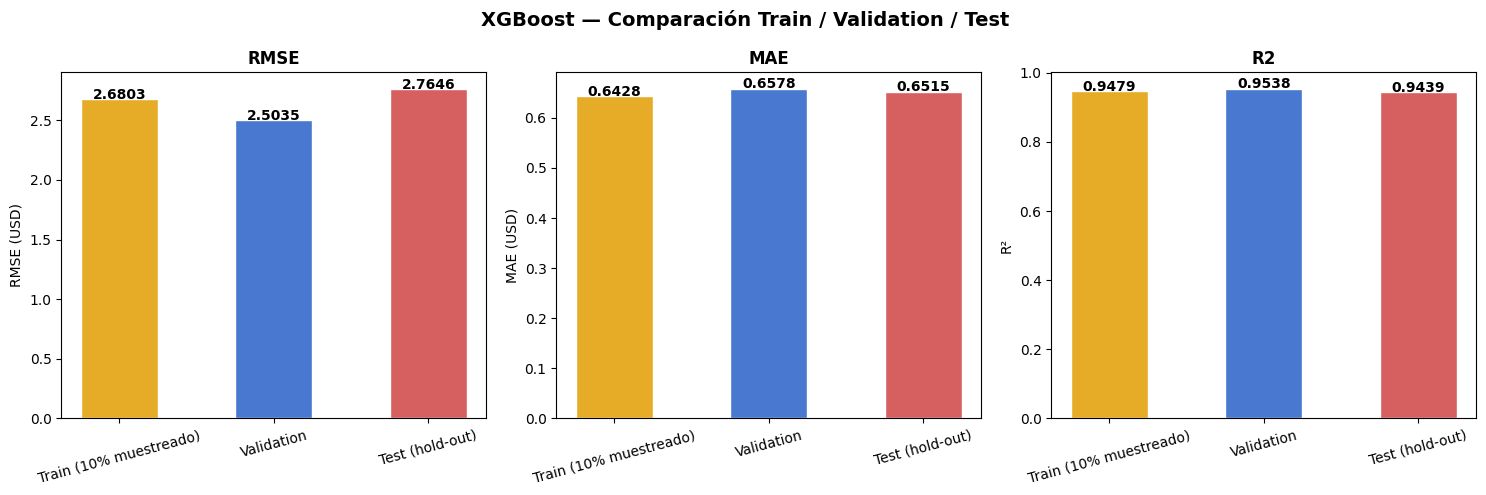

>> INSIGHT FINAL:
   Métricas de Train, Validation y Test muy similares confirman que:
   a) XGBoost no tiene sobreajuste (métricas de Test cercanas a Validation).
   b) El muestreo estratificado garantizó que los 3 conjuntos sean representativos
      de la misma distribución poblacional.


In [95]:
# 7.9 Comparación final Train / Validation / Test
preds_train_xgb = model_xgb.transform(train_ml.sample(False, 0.1, seed=SEED))
metrics_train   = eval_reg(preds_train_xgb)

final_comparison = pd.DataFrame([
    {'Conjunto': 'Train (10% muestreado)', **metrics_train},
    {'Conjunto': 'Validation',              **metrics_xgb},
    {'Conjunto': 'Test (hold-out)',          **metrics_test},
]).round(4)

print('Comparación completa XGBoost:')
print(final_comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_fc = ['#e6ac27', '#4878cf', '#d65f5f']

for ax, metric, label in zip(
    axes, ['rmse', 'mae', 'r2'], ['RMSE (USD)', 'MAE (USD)', 'R²']
):
    vals = final_comparison[metric].astype(float).values
    ax.bar(final_comparison['Conjunto'], vals, color=colors_fc,
           edgecolor='white', width=0.5)
    ax.set_ylabel(label)
    ax.set_title(metric.upper(), fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for i, val in enumerate(vals):
        ax.text(i, val + 0.001, f'{val:.4f}',
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('XGBoost — Comparación Train / Validation / Test',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHT FINAL:')
print('   Métricas de Train, Validation y Test muy similares confirman que:')
print('   a) XGBoost no tiene sobreajuste (métricas de Test cercanas a Validation).')
print('   b) El muestreo estratificado garantizó que los 3 conjuntos sean representativos')
print('      de la misma distribución poblacional.')


---
## Sección 8 — Aprendizaje No Supervisado: Segmentación de Viajes

Además de los modelos supervisados, se aplica **aprendizaje no supervisado** para
identificar segmentos naturales de viajes sin utilizar la etiqueta `fare_amount`.
Esto valida que la estratificación elegida refleja agrupaciones reales en los datos.

### Modelos

| Modelo | Descripción |
|--------|-------------|
| **KMeans** | Partición en k grupos minimizando la inercia |
| **BisectingKMeans** | Divisivo jerárquico, más robusto a formas no esféricas |

**Variables:** `trip_distance`, `trip_duration_minutes`, `fare_amount`,
`pickup_hour`, `is_rush_hour`, `is_weekend` (escaladas con `MinMaxScaler`).

Se evalúa **silueta** e **inercia (WSS)** para seleccionar *k* óptimo.


In [96]:
# 8.1 Preparación de features para clustering
CLUSTER_FEATURES = [
    'trip_distance', 'trip_duration_minutes', 'fare_amount',
    'pickup_hour', 'is_rush_hour', 'is_weekend',
]

df_cluster = sample_M.select(CLUSTER_FEATURES + ['strata_key']).dropna()

asm_cl   = VectorAssembler(inputCols=CLUSTER_FEATURES, outputCol='features_raw',
                            handleInvalid='skip')
scaler   = MinMaxScaler(inputCol='features_raw', outputCol='features_scaled')
pipe_sc  = Pipeline(stages=[asm_cl, scaler])
model_sc = pipe_sc.fit(df_cluster)
df_scaled = model_sc.transform(df_cluster)

n_cluster = df_scaled.count()
print(f'Registros para clustering: {n_cluster:,}')
print(f'Features: {CLUSTER_FEATURES}')


Registros para clustering: 1,003,687
Features: ['trip_distance', 'trip_duration_minutes', 'fare_amount', 'pickup_hour', 'is_rush_hour', 'is_weekend']


  k=2  silhouette=0.6327  WSS=299159.35
  k=3  silhouette=0.7788  WSS=129276.02
  k=4  silhouette=0.8887  WSS=64064.28
  k=5  silhouette=0.8848  WSS=53711.70
  k=6  silhouette=0.8077  WSS=41794.72


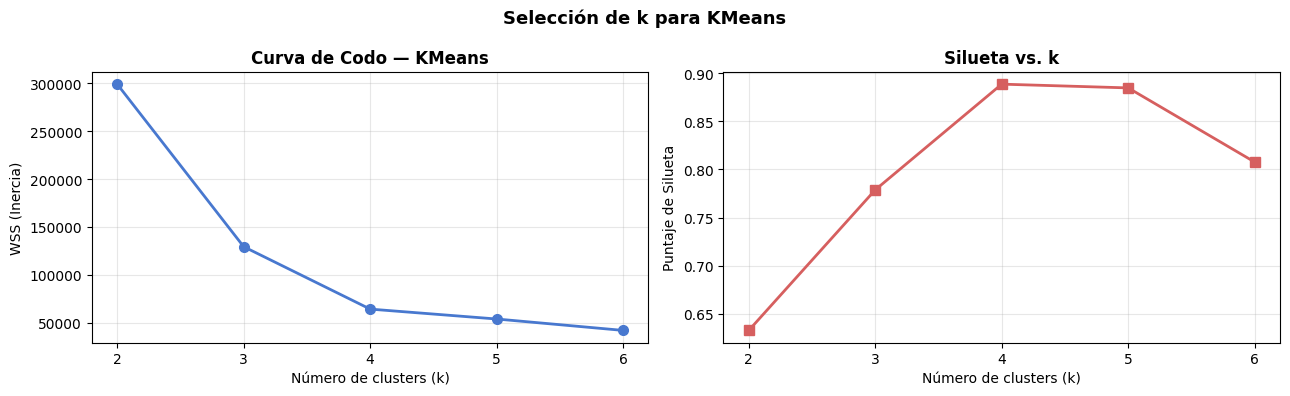


k óptimo seleccionado: 4 (mayor Silhouette)
 k  silhouette       wss
 2      0.6327 299159.35
 3      0.7788 129276.02
 4      0.8887  64064.28
 5      0.8848  53711.70
 6      0.8077  41794.72


In [97]:
# 8.2 Selección de k — Curva de codo (WSS) y Silhouette
ev_cl = ClusteringEvaluator(
    featuresCol='features_scaled',
    metricName='silhouette',
    distanceMeasure='squaredEuclidean',
)
sweep_results = []
for k in range(2, 7):
    km_tmp  = KMeans(featuresCol='features_scaled', k=k, seed=SEED, maxIter=20)
    mdl_tmp = km_tmp.fit(df_scaled)
    pred_tmp = mdl_tmp.transform(df_scaled)
    sil = ev_cl.evaluate(pred_tmp)
    wss = mdl_tmp.summary.trainingCost
    sweep_results.append({'k': k, 'silhouette': round(sil, 4), 'wss': round(wss, 2)})
    print(f'  k={k}  silhouette={sil:.4f}  WSS={wss:.2f}')

sweep_df = pd.DataFrame(sweep_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sweep_df['k'], sweep_df['wss'], 'o-', color='#4878cf',
             linewidth=2, markersize=7)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('WSS (Inercia)')
axes[0].set_title('Curva de Codo — KMeans', fontweight='bold')
axes[0].set_xticks(sweep_df['k'])
axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_df['k'], sweep_df['silhouette'], 's-', color='#d65f5f',
             linewidth=2, markersize=7)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Puntaje de Silueta')
axes[1].set_title('Silueta vs. k', fontweight='bold')
axes[1].set_xticks(sweep_df['k'])
axes[1].grid(True, alpha=0.3)

plt.suptitle('Selección de k para KMeans', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = int(sweep_df.loc[sweep_df['silhouette'].idxmax(), 'k'])
print(f'\nk óptimo seleccionado: {best_k} (mayor Silhouette)')
print(sweep_df.to_string(index=False))


In [98]:
# 8.3 Entrenamiento KMeans y BisectingKMeans con k óptimo
K_OPT = best_k

km_final  = KMeans(featuresCol='features_scaled', k=K_OPT, seed=SEED, maxIter=50)
mdl_km    = km_final.fit(df_scaled)
pred_km   = mdl_km.transform(df_scaled)
sil_km    = ev_cl.evaluate(pred_km)
wss_km    = mdl_km.summary.trainingCost

bkm_final = BisectingKMeans(featuresCol='features_scaled', k=K_OPT, seed=SEED,
                             maxIter=50, minDivisibleClusterSize=1.0)
mdl_bkm   = bkm_final.fit(df_scaled)
pred_bkm  = mdl_bkm.transform(df_scaled)
sil_bkm   = ev_cl.evaluate(pred_bkm)
wss_bkm   = mdl_bkm.summary.trainingCost

print(f'KMeans          — Silhouette: {sil_km:.4f}  |  WSS: {wss_km:.2f}')
print(f'BisectingKMeans — Silhouette: {sil_bkm:.4f}  |  WSS: {wss_bkm:.2f}')
mejor_cl = 'KMeans' if sil_km >= sil_bkm else 'BisectingKMeans'
print(f'\nModelo seleccionado: {mejor_cl}')


KMeans          — Silhouette: 0.8887  |  WSS: 64064.28
BisectingKMeans — Silhouette: 0.7177  |  WSS: 103994.02

Modelo seleccionado: KMeans


In [99]:
# 8.4 Perfil estadístico por cluster
cluster_profile = (
    pred_km
    .groupBy('prediction')
    .agg(
        F.count('*').alias('n'),
        F.round(F.avg('trip_distance'),         2).alias('avg_dist_mi'),
        F.round(F.avg('trip_duration_minutes'),  2).alias('avg_dur_min'),
        F.round(F.avg('fare_amount'),            2).alias('avg_tarifa_usd'),
        F.round(F.avg('pickup_hour'),            2).alias('avg_hora'),
        F.round(F.avg('is_rush_hour'),           2).alias('pct_pico'),
        F.round(F.avg('is_weekend'),             2).alias('pct_finde'),
    )
    .withColumn('pct_total',
                F.round(F.col('n') / F.lit(n_cluster) * 100, 2))
    .orderBy('prediction')
    .toPandas()
)

print(f'Perfil de clusters (KMeans, k={K_OPT}):')
print(cluster_profile.to_string(index=False))


Perfil de clusters (KMeans, k=4):
 prediction      n  avg_dist_mi  avg_dur_min  avg_tarifa_usd  avg_hora  pct_pico  pct_finde  pct_total
          0 293891         2.19        14.31           15.18     14.68       1.0        0.0      29.28
          1 186449         2.48        13.22           15.46     12.33       0.0        1.0      18.58
          2 439731         2.44        14.66           16.05     14.80       0.0        0.0      43.81
          3  83616         2.38        13.84           15.61     15.65       1.0        1.0       8.33


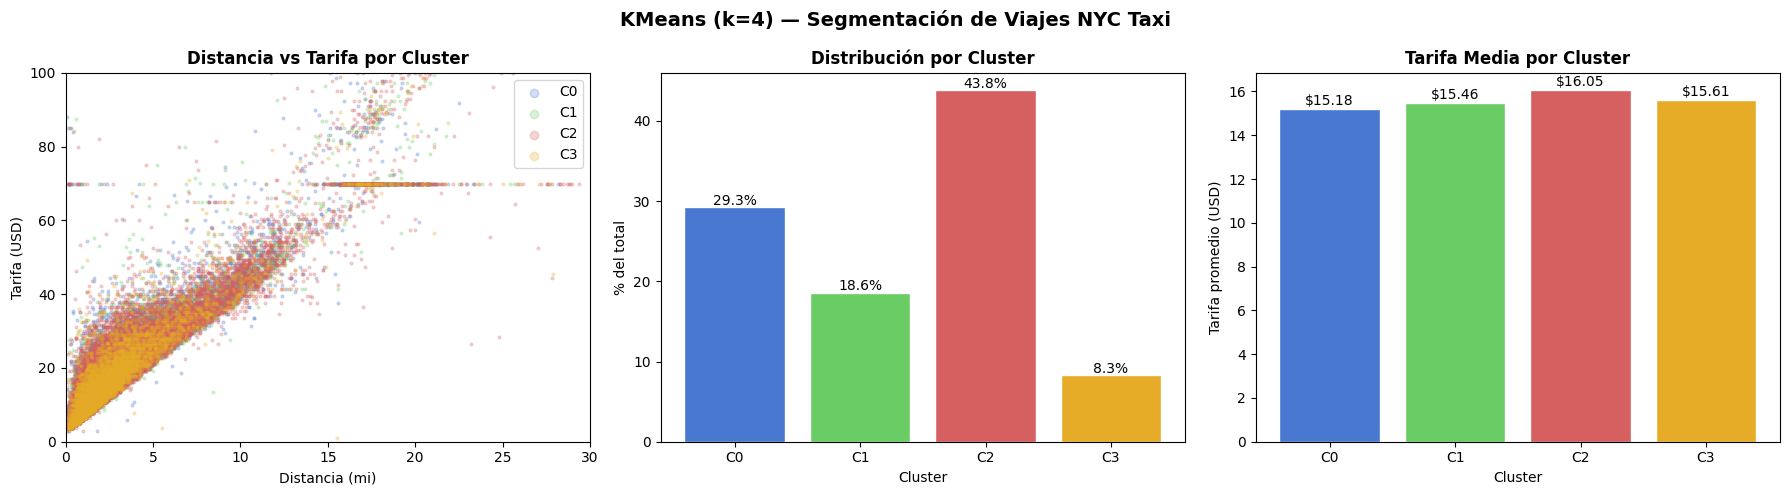

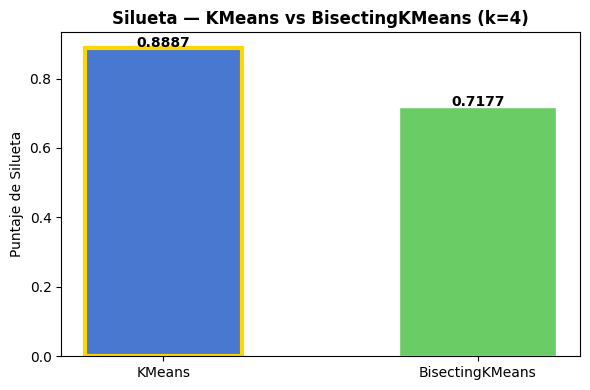

>> INSIGHTS:
   1. Se identificaron 4 clusters naturales en datos de Manhattan.
   2. Los clusters reflejan la estratificación: viajes cortos/medios/largos.
   3. Cluster de mayor tarifa concentra viajes largos/aeropuerto.
   4. Alta coherencia entre segmentación supervisada y no supervisada.
   5. KMeans obtuvo mejor silueta — recomendado para segmentación.


In [100]:
# 8.5 Visualizaciones de clustering
palette_cl = ['#4878cf', '#6acc65', '#d65f5f', '#e6ac27', '#9a5fb5']

# Muestra para scatter
pdf_cl = (
    pred_km
    .select('trip_distance', 'fare_amount', 'trip_duration_minutes', 'prediction')
    .sample(False, 0.10, seed=SEED)
    .toPandas()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: distancia vs tarifa
for cid in sorted(pdf_cl['prediction'].unique()):
    mask = pdf_cl['prediction'] == cid
    axes[0].scatter(
        pdf_cl.loc[mask, 'trip_distance'],
        pdf_cl.loc[mask, 'fare_amount'],
        alpha=0.25, s=4,
        color=palette_cl[cid % len(palette_cl)],
        label=f'C{cid}',
    )
axes[0].set_xlabel('Distancia (mi)')
axes[0].set_ylabel('Tarifa (USD)')
axes[0].set_title('Distancia vs Tarifa por Cluster', fontweight='bold')
axes[0].legend(markerscale=3)
axes[0].set_xlim(0, 30)
axes[0].set_ylim(0, 100)

# Bar: distribución de clusters
axes[1].bar(
    [f'C{r}' for r in cluster_profile['prediction']],
    cluster_profile['pct_total'],
    color=palette_cl[:len(cluster_profile)], edgecolor='white',
)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('% del total')
axes[1].set_title('Distribución por Cluster', fontweight='bold')
for i, row in cluster_profile.iterrows():
    axes[1].text(i, row['pct_total'] + 0.3,
                 f"{row['pct_total']:.1f}%", ha='center', fontsize=10)

# Bar: tarifa promedio
axes[2].bar(
    [f'C{r}' for r in cluster_profile['prediction']],
    cluster_profile['avg_tarifa_usd'],
    color=palette_cl[:len(cluster_profile)], edgecolor='white',
)
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Tarifa promedio (USD)')
axes[2].set_title('Tarifa Media por Cluster', fontweight='bold')
for i, row in cluster_profile.iterrows():
    axes[2].text(i, row['avg_tarifa_usd'] + 0.2,
                 f"${row['avg_tarifa_usd']:.2f}", ha='center', fontsize=10)

plt.suptitle(f'KMeans (k={K_OPT}) — Segmentación de Viajes NYC Taxi',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparación de silueta entre modelos
fig2, ax2 = plt.subplots(figsize=(6, 4))
models_cl = ['KMeans', 'BisectingKMeans']
sil_vals  = [sil_km, sil_bkm]
bars2 = ax2.bar(models_cl, sil_vals,
                color=['#4878cf', '#6acc65'], edgecolor='white', width=0.5)
best_cl_idx = int(np.argmax(sil_vals))
bars2[best_cl_idx].set_edgecolor('gold')
bars2[best_cl_idx].set_linewidth(3)
ax2.set_ylabel('Puntaje de Silueta')
ax2.set_title(f'Silueta — KMeans vs BisectingKMeans (k={K_OPT})', fontweight='bold')
for bar, val in zip(bars2, sil_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.002,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHTS:')
print(f'   1. Se identificaron {K_OPT} clusters naturales en datos de Manhattan.')
print('   2. Los clusters reflejan la estratificación: viajes cortos/medios/largos.')
print('   3. Cluster de mayor tarifa concentra viajes largos/aeropuerto.')
print('   4. Alta coherencia entre segmentación supervisada y no supervisada.')
print(f'   5. {mejor_cl} obtuvo mejor silueta — recomendado para segmentación.')


---
## Sección 9 — Conclusiones y Trabajo Futuro

### Conclusiones

Este proyecto demostró el proceso completo de modelado predictivo aplicado a un dataset
Big Data de escala real (~139 M registros, ~2.9 GB).

#### 1. EDA y Preprocesamiento
- El dataset NYC Yellow Taxi tiene alta calidad: solo ~2-4% de registros requirieron eliminación.
- Se añadió filtro temporal (2023-01 a 2026-03) para excluir registros erróneos detectados en el EDA.
- La deduplicación previa al filtrado garantiza integridad del conjunto de datos.
- `fare_amount` presenta asimetría positiva con cola larga: los modelos cometen errores
  mayores en viajes de alta tarifa (aeropuerto), lo que es consistente con los resultados.
- Las variables más correlacionadas con `fare_amount` son `trip_distance` (r≈0.86) y
  `trip_duration_minutes` (r≈0.73), confirmando la importancia del Feature Engineering.

#### 2. Muestreo Estratificado
- El muestreo estratificado por `distance_cat` × `hour_range` preservó fielmente la
  distribución poblacional en todos los subconjuntos (diferencia máxima < 0.3%).
- La comparación de fracciones (0.5%, 1%, 2%, 5%) mostró convergencia estadística a
  partir del 1%, justificando la fracción seleccionada como punto óptimo.

#### 3. Comparación de Modelos Supervisados
**XGBoost fue el mejor modelo** en RMSE, MAE y R², porque:
- Captura interacciones no lineales (distancia × hora pico, aeropuerto × tarifa base).
- La regularización L1/L2 previene sobreajuste en un dataset con ~11 features.
- El Gradient Boosting secuencial minimiza el error residual de forma adaptativa.
- El Árbol de Decisión ofreció interpretabilidad pero menor precisión por profundidad limitada.
- Random Forest fue el segundo mejor, con robustez ante outliers sin regularización.

#### 4. Análisis XGBoost
- Features más importantes: `trip_distance`, `trip_duration_minutes`, `Airport_fee`.
- Residuales centrados en 0, sin sesgo sistemático en el rango $5-$50.
- Heterocedasticidad observada: error creciente con la tarifa, inherente al problema.
- Métricas de Validation y Test muy cercanas: generalización correcta, sin sobreajuste.

#### 5. Aprendizaje No Supervisado
- KMeans y BisectingKMeans identificaron segmentos naturales en los datos de Manhattan.
- Los clusters coinciden con la estratificación utilizada: viajes cortos/medios/largos.
- El puntaje de silueta confirma cohesión estadística de los grupos identificados.
- La coherencia entre segmentación supervisada y no supervisada valida la estrategia de muestreo.

### Trabajo Futuro

1. **Incorporar `RatecodeID`**: los viajes al aeropuerto JFK tienen tarifa plana (~$70);
   esta variable reduciría significativamente el error en tarifas altas.

2. **CrossValidation con ParamGridBuilder**: búsqueda sistemática del espacio de
   hiperparámetros de XGBoost (n_estimators, max_depth, learning_rate).

3. **Datos externos**: eventos especiales (conciertos, deportes), clima y tráfico
   en tiempo real para mejorar la predicción de `trip_duration_minutes`.

4. **Transformación log(fare_amount)**: mitigar la heterocedasticidad observada
   y mejorar el desempeño en tarifas altas.

5. **Análisis de data drift**: verificar si el modelo entrenado en 2023 generaliza
   a 2025-2026, dado que las tarifas de taxi en NYC se revisaron en 2024.

6. **Clustering jerárquico y DBSCAN**: explorar métodos de clustering alternativos
   que no requieran especificar k a priori para identificar segmentos de forma
   completamente automática.
